<a href="https://colab.research.google.com/github/mic006016/seoul-commercial-district-analysis/blob/main/Project2_DataPrep_EDA_FeatureSelection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from scipy.optimize import minimize

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/drive/MyDrive/seoul_cma_data_v2.csv')
df.head(5)

,ds,year,quarter,yq_cd,gu_cd,gu_nm,dong_cd,dong_nm,biz_cd,biz_nm,...,fclty_bus_term_cnt,fclty_subway_cnt,fclty_bus_stop_cnt,change_idx,change_idx_nm,open_avg_months,close_avg_months,coord_x,coord_y,dong_area
0,2019-01-01,2019,1,20191,11110,종로구,11110515,청운효자동,CS100001,한식음식점,...,0.0,0.0,26.0,LH,상권확장,86,52,197342,453874,2568432
1,2019-04-01,2019,2,20192,11110,종로구,11110515,청운효자동,CS100001,한식음식점,...,0.0,0.0,26.0,LH,상권확장,86,52,197342,453874,2568432
2,2019-07-01,2019,3,20193,11110,종로구,11110515,청운효자동,CS100001,한식음식점,...,0.0,0.0,26.0,LH,상권확장,85,49,197342,453874,2568432
3,2019-10-01,2019,4,20194,11110,종로구,11110515,청운효자동,CS100001,한식음식점,...,0.0,0.0,26.0,LH,상권확장,87,49,197342,453874,2568432
4,2020-01-01,2020,1,20201,11110,종로구,11110515,청운효자동,CS100001,한식음식점,...,0.0,0.0,26.0,LH,상권확장,87,50,197342,453874,2568432


In [4]:
df.shape

(408221, 144)

## EDA

STEP 1. 결측치 체크

In [5]:
print("=== 컬럼별 결측치 개수 및 비율 ===")
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Ratio (%)': (df.isnull().sum() / len(df)) * 100
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

=== 컬럼별 결측치 개수 및 비율 ===
              Missing Count  Missing Ratio (%)
wk_pop_20s             4597           1.126106
wk_pop_30s             4597           1.126106
wk_pop_40s             4597           1.126106
wk_pop_50s             4597           1.126106
wk_pop_tot             4597           1.126106
wk_pop_60s             4597           1.126106
wk_pop_10s             4597           1.126106
wk_pop_f               4597           1.126106
wk_pop_m               4597           1.126106
rs_pop_tot              724           0.177355
rs_pop_10s              724           0.177355
rs_pop_f                724           0.177355
rs_pop_m                724           0.177355
rs_pop_20s              724           0.177355
rs_hh_nonapt            724           0.177355
rs_hh_tot               724           0.177355
rs_hh_apt               724           0.177355
rs_pop_40s              724           0.177355
rs_pop_50s              724           0.177355
rs_pop_30s              724         

In [6]:
# 1. 직장인구가 비어있는 행정동과 시기(년분기) 추적
missing_wk_pop = df[df['wk_pop_tot'].isnull()][['yq_cd', 'gu_nm', 'dong_nm']].drop_duplicates()

print("\n=== 직장인구 결측치 발생 행정동 및 시기 ===")
# 행정동 -> 시간순으로 정렬
print(missing_wk_pop.sort_values(['dong_nm', 'yq_cd']).to_string(index=False))


# 2. 상주인구가 비어있는 행정동과 시기(년분기) 추적
missing_rs_pop = df[df['rs_pop_tot'].isnull()][['yq_cd', 'gu_nm', 'dong_nm']].drop_duplicates()

print("\n=== 상주인구 결측치 발생 행정동 및 시기 ===")
print(missing_rs_pop.sort_values(['dong_nm', 'yq_cd']).to_string(index=False))


=== 직장인구 결측치 발생 행정동 및 시기 ===
 yq_cd gu_nm dong_nm
 20191   강서구    가양2동
 20192   강서구    가양2동
 20193   강서구    가양2동
 20194   강서구    가양2동
 20201   강서구    가양2동
 20202   강서구    가양2동
 20203   강서구    가양2동
 20204   강서구    가양2동
 20211   강서구    가양2동
 20212   강서구    가양2동
 20213   강서구    가양2동
 20214   강서구    가양2동
 20221   강서구    가양2동
 20222   강서구    가양2동
 20223   강서구    가양2동
 20224   강서구    가양2동
 20231   강서구    가양2동
 20232   강서구    가양2동
 20233   강서구    가양2동
 20234   강서구    가양2동
 20241   강서구    가양2동
 20242   강서구    가양2동
 20243   강서구    가양2동
 20244   강서구    가양2동
 20191   구로구    구로1동
 20192   구로구    구로1동
 20193   구로구    구로1동
 20194   구로구    구로1동
 20201   구로구    구로1동
 20202   구로구    구로1동
 20203   구로구    구로1동
 20204   구로구    구로1동
 20211   구로구    구로1동
 20212   구로구    구로1동
 20213   구로구    구로1동
 20214   구로구    구로1동
 20221   구로구    구로1동
 20222   구로구    구로1동
 20223   구로구    구로1동
 20224   구로구    구로1동
 20231   구로구    구로1동
 20232   구로구    구로1동
 20233   구로구    구로1동
 20234   구로구    구로1동
 20241   구로구    구로1동
 202

In [7]:
# 결측치 처리
# 1. 시계열 채우기(bfill)를 위해 데이터를 다시 한번 정렬
df = df.sort_values(['dong_cd', 'biz_cd', 'yq_cd']).reset_index(drop=True)
df.head(10)

,ds,year,quarter,yq_cd,gu_cd,gu_nm,dong_cd,dong_nm,biz_cd,biz_nm,...,fclty_bus_term_cnt,fclty_subway_cnt,fclty_bus_stop_cnt,change_idx,change_idx_nm,open_avg_months,close_avg_months,coord_x,coord_y,dong_area
0,2019-01-01,2019,1,20191,11110,종로구,11110515,청운효자동,CS100001,한식음식점,...,0.0,0.0,26.0,LH,상권확장,86,52,197342,453874,2568432
1,2019-04-01,2019,2,20192,11110,종로구,11110515,청운효자동,CS100001,한식음식점,...,0.0,0.0,26.0,LH,상권확장,86,52,197342,453874,2568432
2,2019-07-01,2019,3,20193,11110,종로구,11110515,청운효자동,CS100001,한식음식점,...,0.0,0.0,26.0,LH,상권확장,85,49,197342,453874,2568432
3,2019-10-01,2019,4,20194,11110,종로구,11110515,청운효자동,CS100001,한식음식점,...,0.0,0.0,26.0,LH,상권확장,87,49,197342,453874,2568432
4,2020-01-01,2020,1,20201,11110,종로구,11110515,청운효자동,CS100001,한식음식점,...,0.0,0.0,26.0,LH,상권확장,87,50,197342,453874,2568432
5,2020-04-01,2020,2,20202,11110,종로구,11110515,청운효자동,CS100001,한식음식점,...,0.0,0.0,26.0,LH,상권확장,87,50,197342,453874,2568432
6,2020-07-01,2020,3,20203,11110,종로구,11110515,청운효자동,CS100001,한식음식점,...,0.0,0.0,26.0,LH,상권확장,89,50,197342,453874,2568432
7,2020-10-01,2020,4,20204,11110,종로구,11110515,청운효자동,CS100001,한식음식점,...,0.0,0.0,26.0,LH,상권확장,90,50,197342,453874,2568432
8,2021-01-01,2021,1,20211,11110,종로구,11110515,청운효자동,CS100001,한식음식점,...,0.0,0.0,26.0,LH,상권확장,90,50,197342,453874,2568432
9,2021-04-01,2021,2,20212,11110,종로구,11110515,청운효자동,CS100001,한식음식점,...,0.0,0.0,26.0,LH,상권확장,90,51,197342,453874,2568432


In [8]:
# 2. 직장인구(wk_pop) 컬럼 추출 및 0으로 채우기 (순수 주거지역)
wk_cols = [col for col in df.columns if 'wk_pop_' in col]
df[wk_cols] = df[wk_cols].fillna(0)

df.loc[df['dong_nm'] == '가양2동', df.columns.str.startswith('wk_pop_')]

,wk_pop_tot,wk_pop_m,wk_pop_f,wk_pop_10s,wk_pop_20s,wk_pop_30s,wk_pop_40s,wk_pop_50s,wk_pop_60s
238927,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
238928,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
238929,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
238930,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
238931,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
239497,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
239498,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
239499,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
239500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# 3. 상주인구(rs_pop, rs_hh) 컬럼 추출 및 bfill 적용 (행정동 개편 누락)
rs_cols = [col for col in df.columns if 'rs_pop_' in col or 'rs_hh_' in col]
# 행정동과 업종별로 그룹화하여 2019년 4분기 데이터를 1~3분기로 끌어올림
df[rs_cols] = df.groupby(['dong_cd', 'biz_cd'])[rs_cols].bfill()

# 4. (안전장치) bfill 후에도 빈칸이 있다면, 해당 동네는 5년 내내 상주인구가 없는 곳이므로 0 처리
df[rs_cols] = df[rs_cols].fillna(0)

df.loc[df['dong_nm'] == '번1동', df.columns.str.startswith(('yq_cd', 'rs_pop_', 'rs_hh_'))]

,yq_cd,rs_pop_tot,rs_pop_m,rs_pop_f,rs_pop_10s,rs_pop_20s,rs_pop_30s,rs_pop_40s,rs_pop_50s,rs_pop_60s,rs_hh_tot,rs_hh_apt,rs_hh_nonapt
124231,20191,19255.0,9580.0,9675.0,1950.0,3280.0,2930.0,3025.0,3155.0,4915.0,10240.0,0.0,10240.0
124232,20192,19255.0,9580.0,9675.0,1950.0,3280.0,2930.0,3025.0,3155.0,4915.0,10240.0,0.0,10240.0
124233,20193,19255.0,9580.0,9675.0,1950.0,3280.0,2930.0,3025.0,3155.0,4915.0,10240.0,0.0,10240.0
124234,20194,19255.0,9580.0,9675.0,1950.0,3280.0,2930.0,3025.0,3155.0,4915.0,10240.0,0.0,10240.0
124235,20201,19255.0,9580.0,9675.0,1950.0,3280.0,2930.0,3025.0,3155.0,4915.0,10240.0,0.0,10240.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
125454,20202,19255.0,9580.0,9675.0,1950.0,3280.0,2930.0,3025.0,3155.0,4915.0,10240.0,0.0,10240.0
125455,20203,19255.0,9580.0,9675.0,1950.0,3280.0,2930.0,3025.0,3155.0,4915.0,10240.0,0.0,10240.0
125456,20204,19057.0,9573.0,9484.0,1792.0,3283.0,2816.0,2946.0,3130.0,5090.0,10476.0,0.0,10476.0
125457,20224,19824.0,9799.0,10025.0,1760.0,2113.0,3156.0,3264.0,3217.0,6314.0,10476.0,0.0,10476.0


In [10]:
# 5. 결과 확인
print("=== 인구 데이터 결측치 처리 완료 ===")
print(f"남은 직장인구 결측치: {df[wk_cols].isnull().sum().sum()}개")
print(f"남은 상주인구 결측치: {df[rs_cols].isnull().sum().sum()}개")

=== 인구 데이터 결측치 처리 완료 ===
남은 직장인구 결측치: 0개
남은 상주인구 결측치: 0개


In [11]:
# 결측치 여부 재검사
print("=== 컬럼별 결측치 개수 및 비율 재검사 ===")
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Ratio (%)': (df.isnull().sum() / len(df)) * 100
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

=== 컬럼별 결측치 개수 및 비율 재검사 ===
Empty DataFrame
Columns: [Missing Count, Missing Ratio (%)]
Index: []


STEP 2. 시계열 패널 데이터 연속성 확인

전체 상권-업종 조합 수: 19335
총 24개 분기가 모두 존재하는 조합의 비율: 73.70%


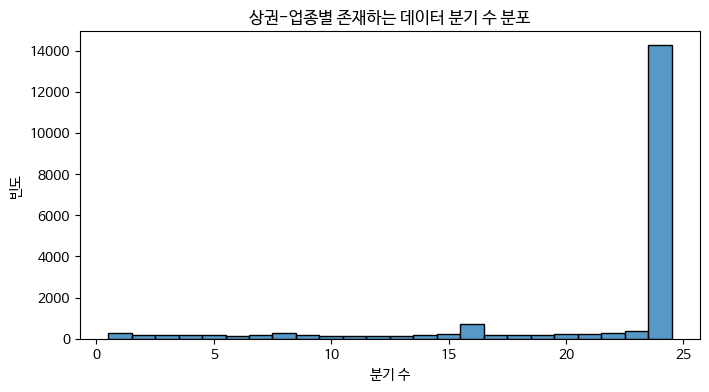

In [12]:
# 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 행정동(dong_cd)과 업종(biz_cd) 조합별로 데이터가 존재하는 분기(yq_cd) 수 확인
continuity_check = df.groupby(['dong_cd', 'biz_cd'])['yq_cd'].nunique()

print("전체 상권-업종 조합 수:", len(continuity_check))
print("총 24개 분기가 모두 존재하는 조합의 비율: {:.2f}%".format((continuity_check == 24).mean() * 100))

# 24개 분기가 안 되는(중간에 생기거나 폐업한) 조합이 얼마나 되는지 분포 확인
plt.figure(figsize=(8, 4))
sns.histplot(continuity_check, bins=24, discrete=True)
plt.title("상권-업종별 존재하는 데이터 분기 수 분포")
plt.xlabel("분기 수")
plt.ylabel("빈도")
plt.show()

In [13]:
incomplete_combi = continuity_check[continuity_check < 24]

samples = incomplete_combi.sample(3, random_state=42)

print("이빨 빠진 데이터 확인 (존재하는 분기 수):")
print(samples, "\n")

for dong_cd, biz_cd in samples.index:
  sample_df = df[(df['dong_cd'] == dong_cd) & (df['biz_cd'] == biz_cd)]

  dong_nm = sample_df['dong_nm'].iloc[0]
  biz_nm = sample_df['biz_nm'].iloc[0]

  existing_quarters = sample_df['yq_cd'].sort_values().tolist()

  print(f"[{dong_nm}({dong_cd}) - {biz_nm}({biz_cd})]")
  print(f"총 {len(existing_quarters)}개 분기 데이터 존재:")
  print(existing_quarters)
  print("-" * 50)

이빨 빠진 데이터 확인 (존재하는 분기 수):
dong_cd   biz_cd  
11380625  CS300031    11
11440585  CS300019    23
11500535  CS300003    23
Name: yq_cd, dtype: int64 

[역촌동(11380625) - 가구(CS300031)]
총 11개 분기 데이터 존재:
[20194, 20202, 20211, 20212, 20221, 20222, 20224, 20232, 20233, 20241, 20244]
--------------------------------------------------
[도화동(11440585) - 의료기기(CS300019)]
총 23개 분기 데이터 존재:
[20192, 20193, 20194, 20201, 20202, 20203, 20204, 20211, 20212, 20213, 20214, 20221, 20222, 20223, 20224, 20231, 20232, 20233, 20234, 20241, 20242, 20243, 20244]
--------------------------------------------------
[등촌3동(11500535) - 컴퓨터및주변장치판매(CS300003)]
총 23개 분기 데이터 존재:
[20191, 20192, 20193, 20194, 20201, 20202, 20203, 20204, 20211, 20212, 20213, 20214, 20221, 20222, 20223, 20224, 20231, 20232, 20233, 20234, 20241, 20242, 20244]
--------------------------------------------------


In [14]:
# 1. TimeGrid 생성 및 병합 (Cross Join 방식)
name_mapping = df.groupby(['dong_cd', 'biz_cd'])[['dong_nm', 'biz_nm']].last().reset_index()
time_grid = name_mapping.merge(pd.DataFrame({'yq_cd': df['yq_cd'].unique()}), how='cross')

df_temp = df.drop(columns=['dong_nm', 'biz_nm'])
df_grid = time_grid.merge(df_temp, on=['dong_cd', 'biz_cd', 'yq_cd'], how='left')

df_grid[(df_grid['dong_cd'] == 11380625) & (df_grid['biz_cd'] == 'CS300031')]

,dong_cd,biz_cd,dong_nm,biz_nm,yq_cd,ds,year,quarter,gu_cd,gu_nm,...,fclty_bus_term_cnt,fclty_subway_cnt,fclty_bus_stop_cnt,change_idx,change_idx_nm,open_avg_months,close_avg_months,coord_x,coord_y,dong_area
199416,11380625,CS300031,역촌동,가구,20191,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199417,11380625,CS300031,역촌동,가구,20192,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199418,11380625,CS300031,역촌동,가구,20193,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199419,11380625,CS300031,역촌동,가구,20194,2019-10-01,2019.0,4.0,11380.0,은평구,...,0.0,0.0,51.0,LL,다이나믹,87.0,45.0,192461.0,456114.0,1157542.0
199420,11380625,CS300031,역촌동,가구,20201,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199421,11380625,CS300031,역촌동,가구,20202,2020-04-01,2020.0,2.0,11380.0,은평구,...,0.0,0.0,51.0,LL,다이나믹,87.0,46.0,192461.0,456114.0,1157542.0
199422,11380625,CS300031,역촌동,가구,20203,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199423,11380625,CS300031,역촌동,가구,20204,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199424,11380625,CS300031,역촌동,가구,20211,2021-01-01,2021.0,1.0,11380.0,은평구,...,0.0,0.0,51.0,LL,다이나믹,90.0,46.0,192461.0,456114.0,1157542.0
199425,11380625,CS300031,역촌동,가구,20212,2021-04-01,2021.0,2.0,11380.0,은평구,...,0.0,0.0,51.0,LL,다이나믹,91.0,47.0,192461.0,456114.0,1157542.0


In [15]:
# 2. NaN으로 채울 업종 컬럼(micro) 정의
micro_cols = [col for col in df.columns if
              col.startswith('sls_') or
              'store' in col or
              col in ['franchise_cnt', 'open_rate', 'close_rate']]

# 3. 같은 '분기-행정동' 안에서 복사해서 채워 넣을 인구/시설(macro) 컬럼 정의
exclude_cols = ['dong_cd', 'dong_nm', 'biz_cd', 'biz_nm' 'yq_cd']
macro_cols = [col for col in df.columns if col not in micro_cols and col not in exclude_cols]

# 4. 같은 '분기-행정동' 그룹 내에 존재하는 값으로 빈칸 채우기
df_grid[macro_cols] = df_grid.groupby(['yq_cd', 'dong_cd'])[macro_cols].transform(lambda x: x.ffill().bfill())

# 5. 시계열 연산을 위한 정렬
df_grid = df_grid.sort_values(by=['dong_cd', 'biz_cd', 'yq_cd']).reset_index(drop=True)

df_grid[(df_grid['dong_cd'] == 11380625) & (df_grid['biz_cd'] == 'CS300031')]

,dong_cd,biz_cd,dong_nm,biz_nm,yq_cd,ds,year,quarter,gu_cd,gu_nm,...,fclty_bus_term_cnt,fclty_subway_cnt,fclty_bus_stop_cnt,change_idx,change_idx_nm,open_avg_months,close_avg_months,coord_x,coord_y,dong_area
199416,11380625,CS300031,역촌동,가구,20191,2019-01-01,2019.0,1.0,11380.0,은평구,...,0.0,0.0,51.0,LL,다이나믹,85.0,45.0,192461.0,456114.0,1157542.0
199417,11380625,CS300031,역촌동,가구,20192,2019-04-01,2019.0,2.0,11380.0,은평구,...,0.0,0.0,51.0,LL,다이나믹,85.0,45.0,192461.0,456114.0,1157542.0
199418,11380625,CS300031,역촌동,가구,20193,2019-07-01,2019.0,3.0,11380.0,은평구,...,0.0,0.0,51.0,LL,다이나믹,87.0,45.0,192461.0,456114.0,1157542.0
199419,11380625,CS300031,역촌동,가구,20194,2019-10-01,2019.0,4.0,11380.0,은평구,...,0.0,0.0,51.0,LL,다이나믹,87.0,45.0,192461.0,456114.0,1157542.0
199420,11380625,CS300031,역촌동,가구,20201,2020-01-01,2020.0,1.0,11380.0,은평구,...,0.0,0.0,51.0,LL,다이나믹,87.0,45.0,192461.0,456114.0,1157542.0
199421,11380625,CS300031,역촌동,가구,20202,2020-04-01,2020.0,2.0,11380.0,은평구,...,0.0,0.0,51.0,LL,다이나믹,87.0,46.0,192461.0,456114.0,1157542.0
199422,11380625,CS300031,역촌동,가구,20203,2020-07-01,2020.0,3.0,11380.0,은평구,...,0.0,0.0,51.0,LL,다이나믹,88.0,46.0,192461.0,456114.0,1157542.0
199423,11380625,CS300031,역촌동,가구,20204,2020-10-01,2020.0,4.0,11380.0,은평구,...,0.0,0.0,51.0,LL,다이나믹,89.0,46.0,192461.0,456114.0,1157542.0
199424,11380625,CS300031,역촌동,가구,20211,2021-01-01,2021.0,1.0,11380.0,은평구,...,0.0,0.0,51.0,LL,다이나믹,90.0,46.0,192461.0,456114.0,1157542.0
199425,11380625,CS300031,역촌동,가구,20212,2021-04-01,2021.0,2.0,11380.0,은평구,...,0.0,0.0,51.0,LL,다이나믹,91.0,47.0,192461.0,456114.0,1157542.0


In [16]:
df_grid[(df_grid['dong_cd'] == 11380625) & (df_grid['biz_cd'] == 'CS300031')][['yq_cd'] + micro_cols]

,yq_cd,store_cnt,similar_store_cnt,open_rate,open_store_cnt,close_rate,close_store_cnt,franchise_cnt,sls_amt_tot,sls_cnt_tot,...,sls_cnt_1721,sls_cnt_2124,sls_cnt_m,sls_cnt_f,sls_cnt_10s,sls_cnt_20s,sls_cnt_30s,sls_cnt_40s,sls_cnt_50s,sls_cnt_60s
199416,20191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199417,20192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199418,20193,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199419,20194,4.0,4.0,0.0,0.0,0.0,0.0,0.0,52184116.0,271.0,...,0.0,0.0,271.0,0.0,0.0,0.0,0.0,271.0,0.0,0.0
199420,20201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199421,20202,4.0,4.0,0.0,0.0,0.0,0.0,0.0,21280276.0,136.0,...,136.0,0.0,0.0,136.0,0.0,0.0,0.0,0.0,0.0,136.0
199422,20203,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199423,20204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199424,20211,5.0,5.0,0.0,0.0,0.0,0.0,0.0,32530358.0,136.0,...,0.0,0.0,0.0,136.0,0.0,0.0,0.0,0.0,136.0,0.0
199425,20212,5.0,5.0,0.0,0.0,0.0,0.0,0.0,338857893.0,271.0,...,271.0,0.0,135.0,136.0,0.0,135.0,0.0,136.0,0.0,0.0


전체 상권-업종 조합 수: 19335
총 24개 분기가 모두 존재하는 조합의 비율: 100.00%


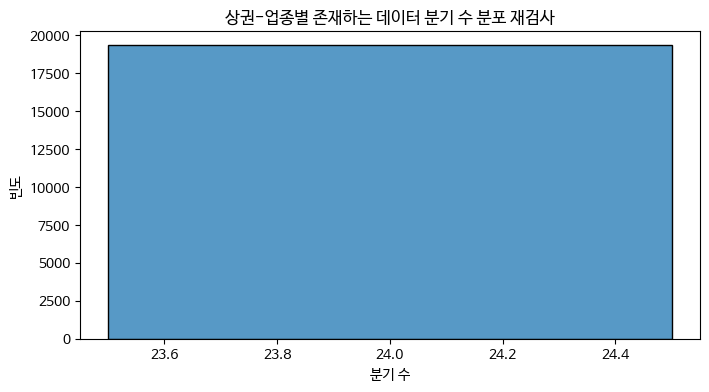

In [17]:
# Time Grid 생성 확인
# 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 행정동(dong_cd)과 업종(biz_cd) 조합별로 데이터가 존재하는 분기(yq_cd) 수 확인
continuity_check = df_grid.groupby(['dong_cd', 'biz_cd'])['yq_cd'].nunique()

print("전체 상권-업종 조합 수:", len(continuity_check))
print("총 24개 분기가 모두 존재하는 조합의 비율: {:.2f}%".format((continuity_check == 24).mean() * 100))

# 24개 분기가 안 되는(중간에 생기거나 폐업한) 조합이 얼마나 되는지 분포 확인
plt.figure(figsize=(8, 4))
sns.histplot(continuity_check, bins=24, discrete=True)
plt.title("상권-업종별 존재하는 데이터 분기 수 분포 재검사")
plt.xlabel("분기 수")
plt.ylabel("빈도")
plt.show()

In [18]:
df = df_grid.copy()

STEP 3. 전체 기간 매출 트렌드 (코로나 및 계절성 파악)

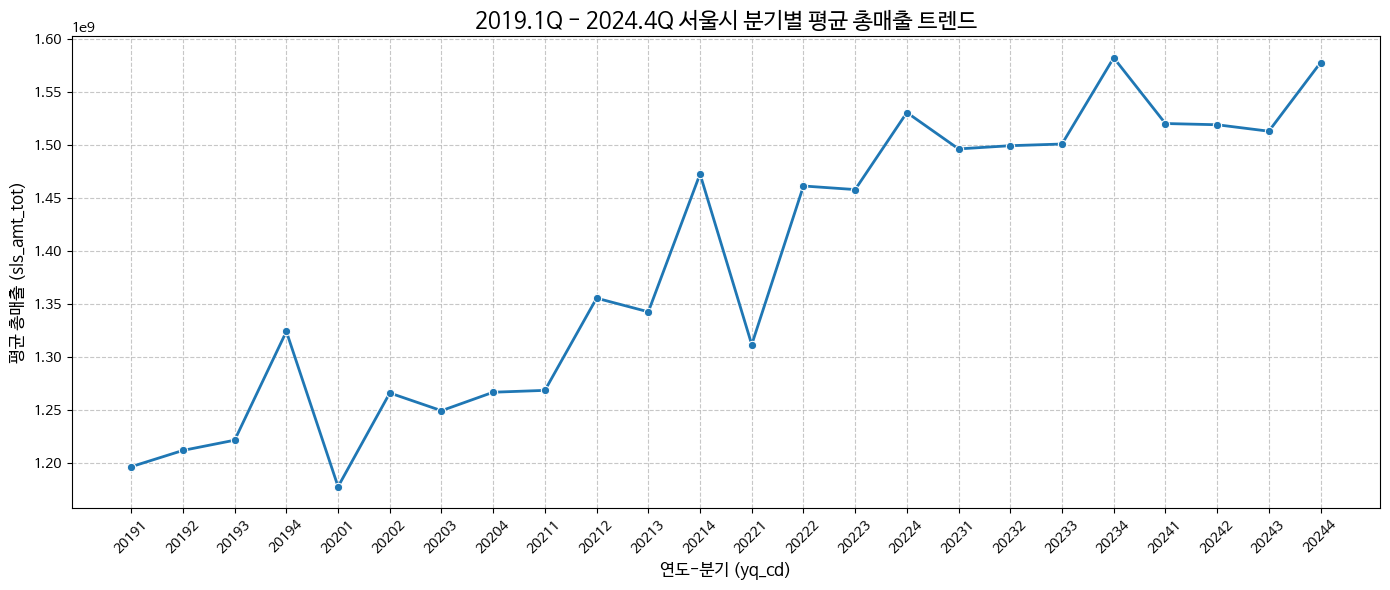

In [19]:
# 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 분기별 평균 총매출 집계
trend_df = df.groupby('yq_cd')['sls_amt_tot'].mean().reset_index()

plt.figure(figsize=(14, 6))
# yq_cd를 문자열로 변환하여 x축이 깔끔하게 나오도록 함
sns.lineplot(data=trend_df, x=trend_df['yq_cd'].astype(str), y='sls_amt_tot', marker='o', linewidth=2)

plt.title("2019.1Q - 2024.4Q 서울시 분기별 평균 총매출 트렌드", fontsize=16)
plt.xlabel("연도-분기 (yq_cd)", fontsize=12)
plt.ylabel("평균 총매출 (sls_amt_tot)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

STEP 4. 지역별 상권 현황 분석

1. 행정동 단위 분석 시각화


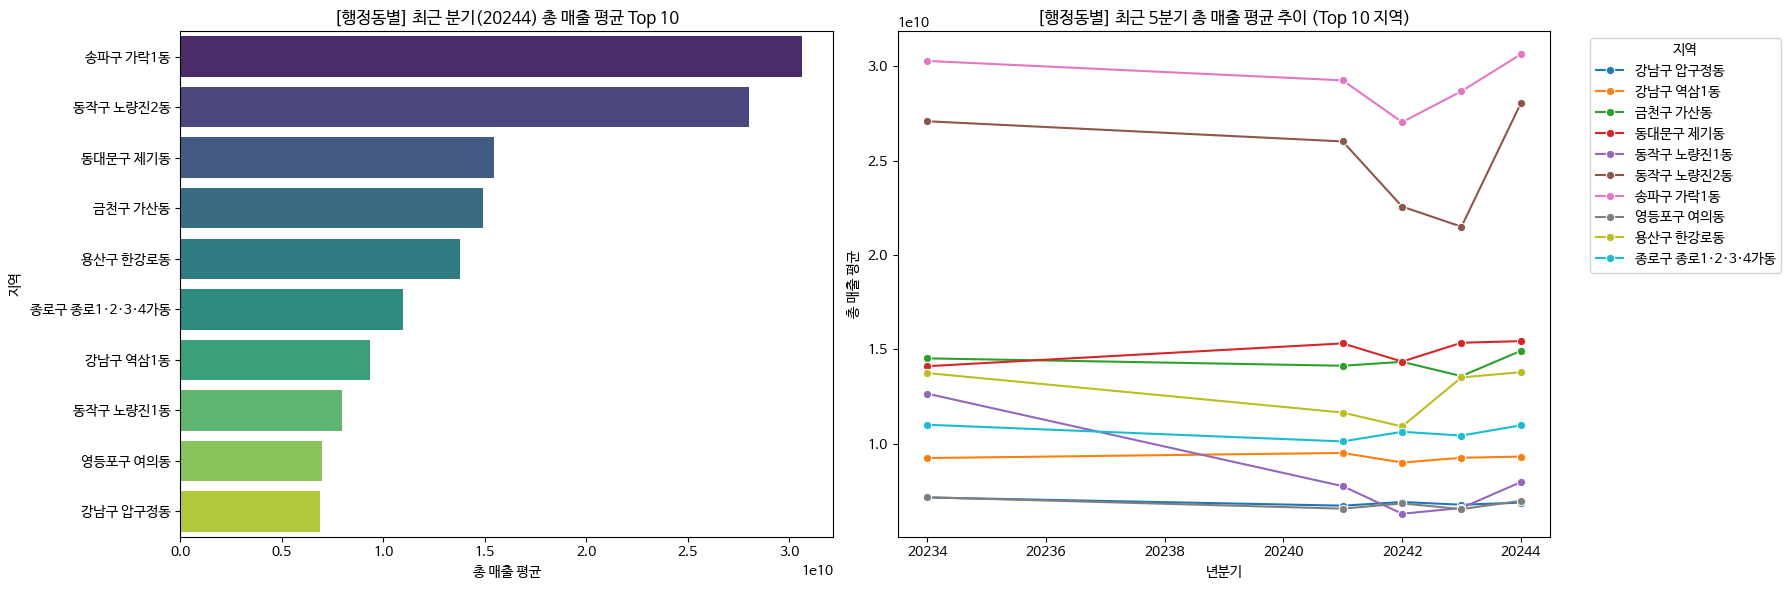

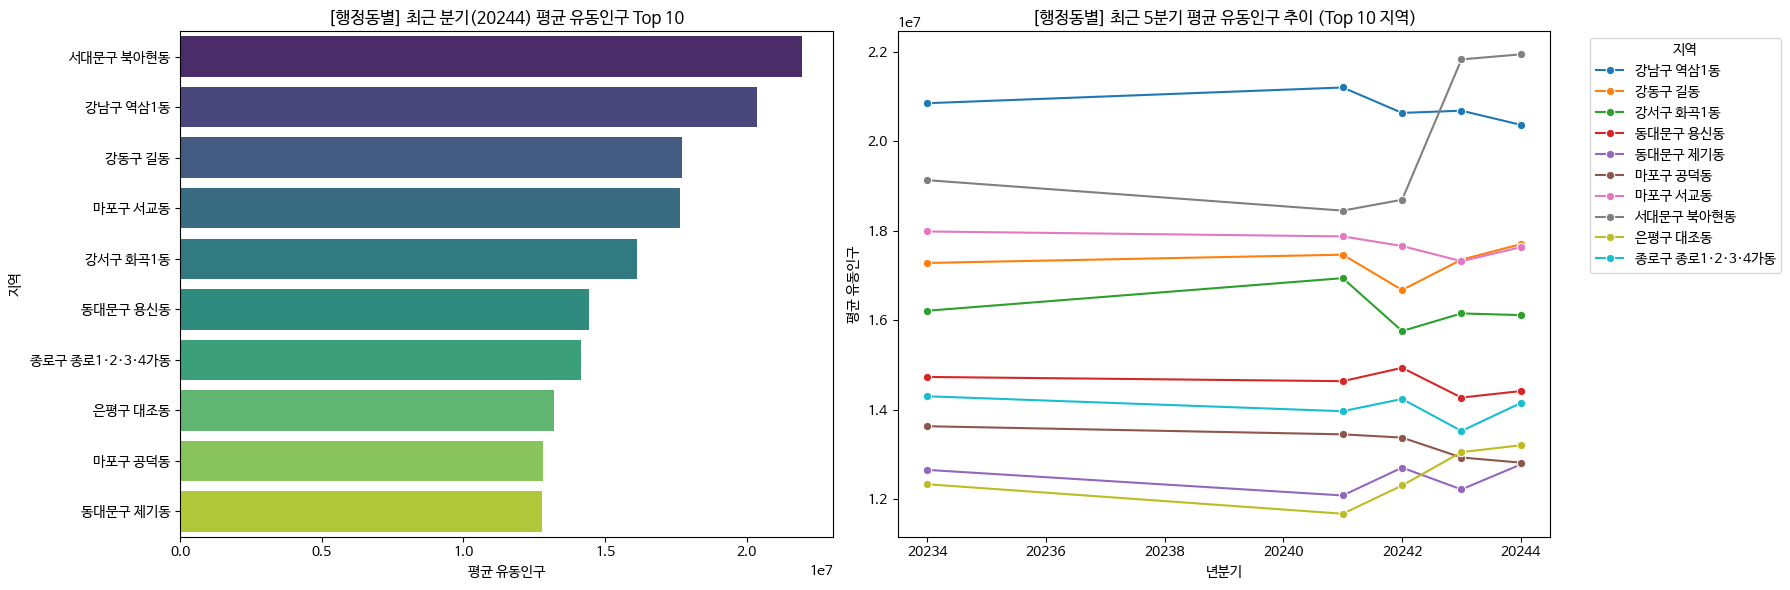


2. 자치구 단위 분석 시각화


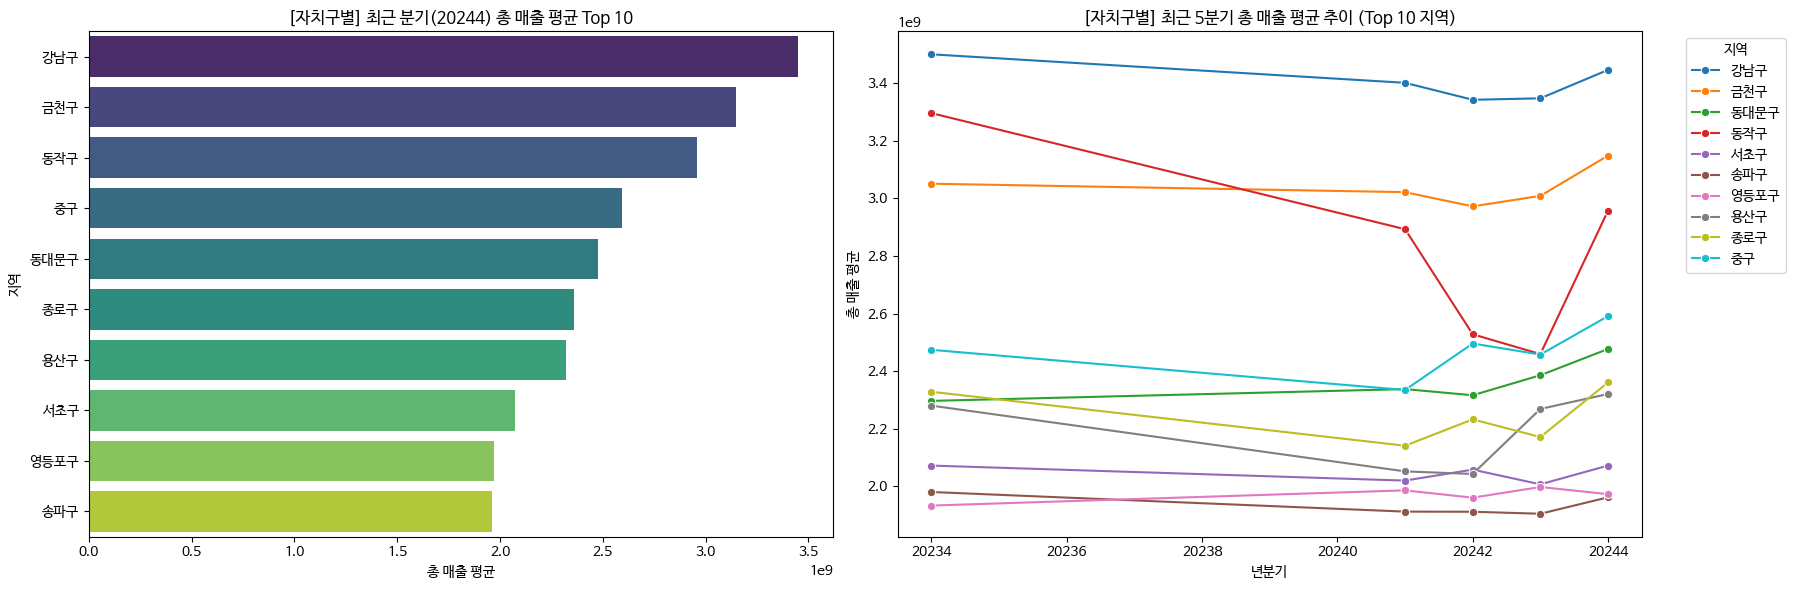

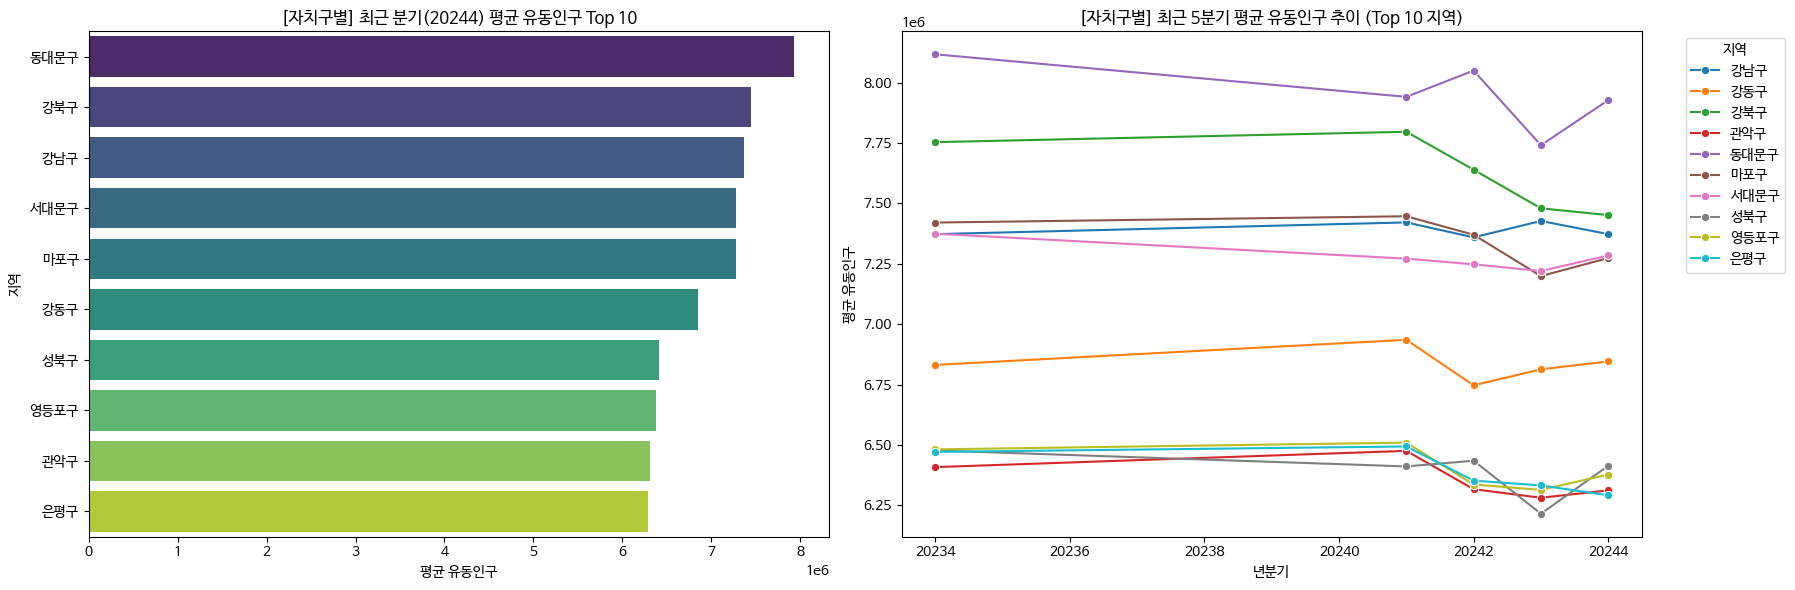

In [39]:
warnings.filterwarnings('ignore')

# 폰트 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# --- 데이터 준비  ---
# 구 이름과 동 이름을 합친 새로운 컬럼 생성
df['gu_dong'] = df['gu_nm'] + ' ' + df['dong_nm']

# 최근 분기와 최근 5개 분기 추출
unique_quarters = sorted(df['yq_cd'].unique())
latest_q = unique_quarters[-1]       # 가장 최근 분기
last_5_q = unique_quarters[-5:]      # 최근 5개 분기

# 분석할 지표 목록
metrics = {
    'sls_amt_tot': '총 매출 평균',
    'fl_pop_tot': '평균 유동인구'
}

def plot_top10_analysis(df, region_col, metric_col, metric_name, title_prefix):

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # 1. 최근 분기 Top 10 (막대 그래프)
    latest_df = df[df['yq_cd'] == latest_q]
    top10_latest = latest_df.groupby(region_col)[metric_col].mean().nlargest(10).reset_index()
    top10_regions = top10_latest[region_col].tolist()

    sns.barplot(
        data=top10_latest,
        x=metric_col,
        y=region_col,
        ax=axes[0],
        palette='viridis'
    )
    axes[0].set_title(f'[{title_prefix}] 최근 분기({latest_q}) {metric_name} Top 10')
    axes[0].set_xlabel(metric_name)
    axes[0].set_ylabel('지역')

    # 2. 최근 5분기 Top 10 꺾은선 그래프
    # 최근 분기 Top 10에 해당하는 지역들만 필터링하고 최근 5분기 데이터만 추출
    trend_df = df[(df[region_col].isin(top10_regions)) & (df['yq_cd'].isin(last_5_q))]
    trend_grouped = trend_df.groupby(['yq_cd', region_col])[metric_col].mean().reset_index()

    sns.lineplot(
        data=trend_grouped,
        x='yq_cd',
        y=metric_col,
        hue=region_col,
        marker='o',
        ax=axes[1],
        palette='tab10'
    )
    axes[1].set_title(f'[{title_prefix}] 최근 5분기 {metric_name} 추이 (Top 10 지역)')
    axes[1].set_xlabel('년분기')
    axes[1].set_ylabel(metric_name)
    axes[1].legend(title='지역', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

# ==========================================
# 1. 행정동 단위 상권 분석
# ==========================================
print("="*50)
print("1. 행정동 단위 분석 시각화")
print("="*50)

for col, name in metrics.items():
    # 데이터셋에 해당 컬럼이 존재하는지 확인 후 실행
    if col in df.columns:
        plot_top10_analysis(df, region_col='gu_dong', metric_col=col, metric_name=name, title_prefix='행정동별')

# ==========================================
# 2.자치구 단위 상권 분석
# ==========================================
print("\n" + "="*50)
print("2. 자치구 단위 분석 시각화")
print("="*50)

for col, name in metrics.items():
    if col in df.columns:
        plot_top10_analysis(df, region_col='gu_nm', metric_col=col, metric_name=name, title_prefix='자치구별')

연평균 성장률(CAGR)

1. 행정동 단위 분석 시각화


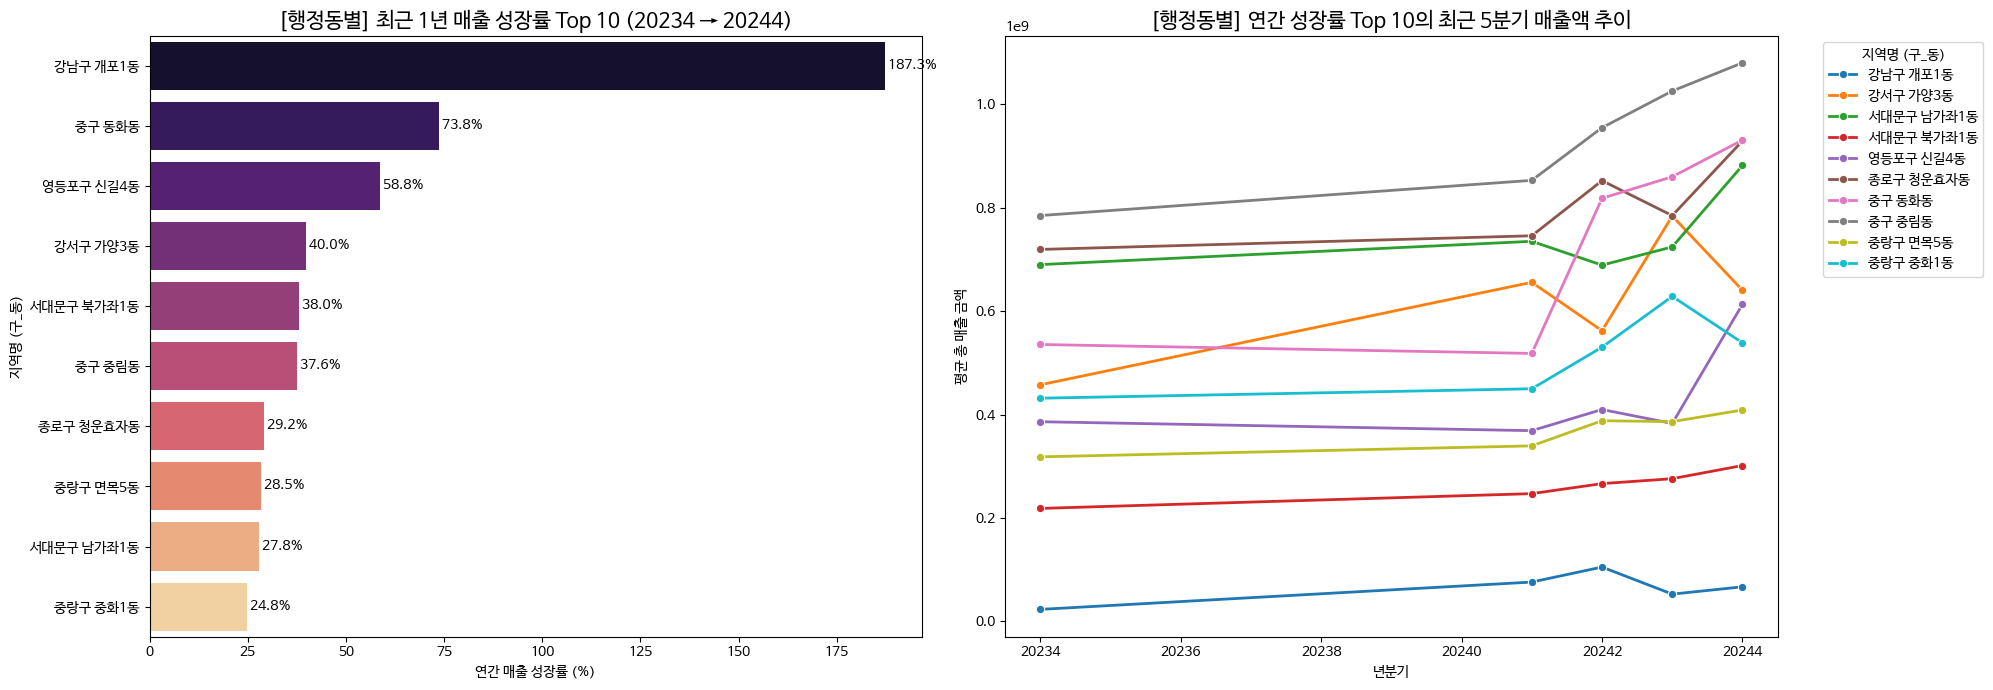


2. 자치구 단위 분석 시각화


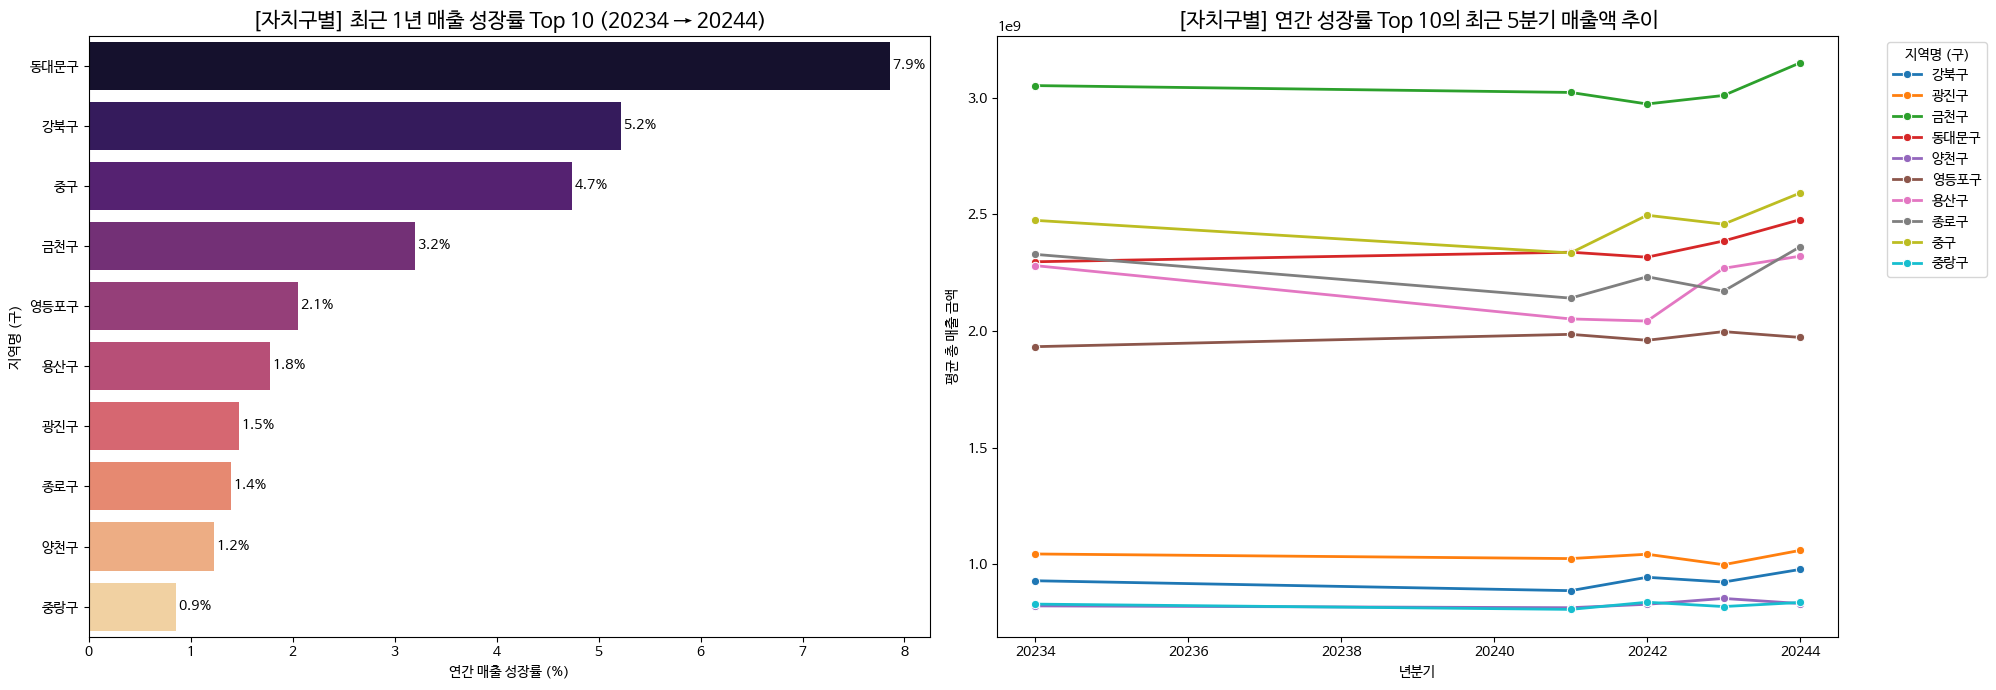

In [41]:
def plot_anual_trend(df, group_col, title_prefix, label_name):
    unique_quarters = sorted(df['yq_cd'].astype(int).unique())

    latest_q = unique_quarters[-1]          # 가장 최근 분기
    past_q = unique_quarters[-5]            # 1년 전 동분기 (비교 대상)
    last_5_q_list = unique_quarters[-5:]    # 최근 5개 분기 리스트 (추이용)

    # 1. 최근 분기와 1년 전 분기의 그룹별 평균 매출 계산
    latest_sales = df[df['yq_cd'] == latest_q].groupby(group_col)['sls_amt_tot'].mean().reset_index()
    past_sales = df[df['yq_cd'] == past_q].groupby(group_col)['sls_amt_tot'].mean().reset_index()

    # 2. 데이터 병합 및 연간 성장률 계산: (최근 매출 / 1년 전 매출) - 1
    cagr_df = pd.merge(latest_sales, past_sales, on=group_col, suffixes=('_latest', '_past'))
    cagr_df['annual_growth_rate'] = (cagr_df['sls_amt_tot_latest'] / cagr_df['sls_amt_tot_past']) - 1

    # 무한대 값 결측치 처리 및 제거
    cagr_df = cagr_df.replace([float('inf'), -float('inf')], pd.NA).dropna(subset=['annual_growth_rate'])

    # 3. 연간 성장률 Top 10 추출
    top10_cagr = cagr_df.nlargest(10, 'annual_growth_rate')
    top10_groups = top10_cagr[group_col].tolist()

    # ---------------------------------------------------------
    # 4. 시각화: 1행 2열 서브플롯 생성
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))

    # [왼쪽] 연간 성장률 Top 10 막대 그래프
    sns.barplot(
        x=top10_cagr['annual_growth_rate'] * 100,
        y=top10_cagr[group_col],
        palette='magma',
        ax=axes[0]
    )
    axes[0].set_title(f'[{title_prefix}] 최근 1년 매출 성장률 Top 10 ({past_q} → {latest_q})', fontsize=15)
    axes[0].set_xlabel('연간 매출 성장률 (%)')
    axes[0].set_ylabel(label_name)

    # 막대 끝에 수치(%) 텍스트 달기
    for index, value in enumerate(top10_cagr['annual_growth_rate']):
        axes[0].text(value * 100, index, f' {value * 100:.1f}%', va='center')

    # [오른쪽] Top 10 그룹의 최근 5분기 추이 꺾은선 그래프
    trend_df = df[(df[group_col].isin(top10_groups)) & (df['yq_cd'].isin(last_5_q_list))]
    trend_grouped = trend_df.groupby(['yq_cd', group_col])['sls_amt_tot'].mean().reset_index()

    sns.lineplot(
        data=trend_grouped,
        x='yq_cd',
        y='sls_amt_tot',
        hue=group_col,
        marker='o',
        linewidth=2,
        ax=axes[1],
        palette='tab10'
    )
    axes[1].set_title(f'[{title_prefix}] 연간 성장률 Top 10의 최근 5분기 매출액 추이', fontsize=15)
    axes[1].set_xlabel('년분기')
    axes[1].set_ylabel('평균 총 매출 금액')
    axes[1].legend(title=label_name, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()


print("="*50)
print("1. 행정동 단위 분석 시각화")
print("="*50)
plot_anual_trend(df, group_col='gu_dong', title_prefix='행정동별', label_name='지역명 (구_동)')

print("\n" + "="*50)
print("2. 자치구 단위 분석 시각화")
print("="*50)
plot_anual_trend(df, group_col='gu_nm', title_prefix='자치구별', label_name='지역명 (구)')

3. 업종 단위 분석 시각화


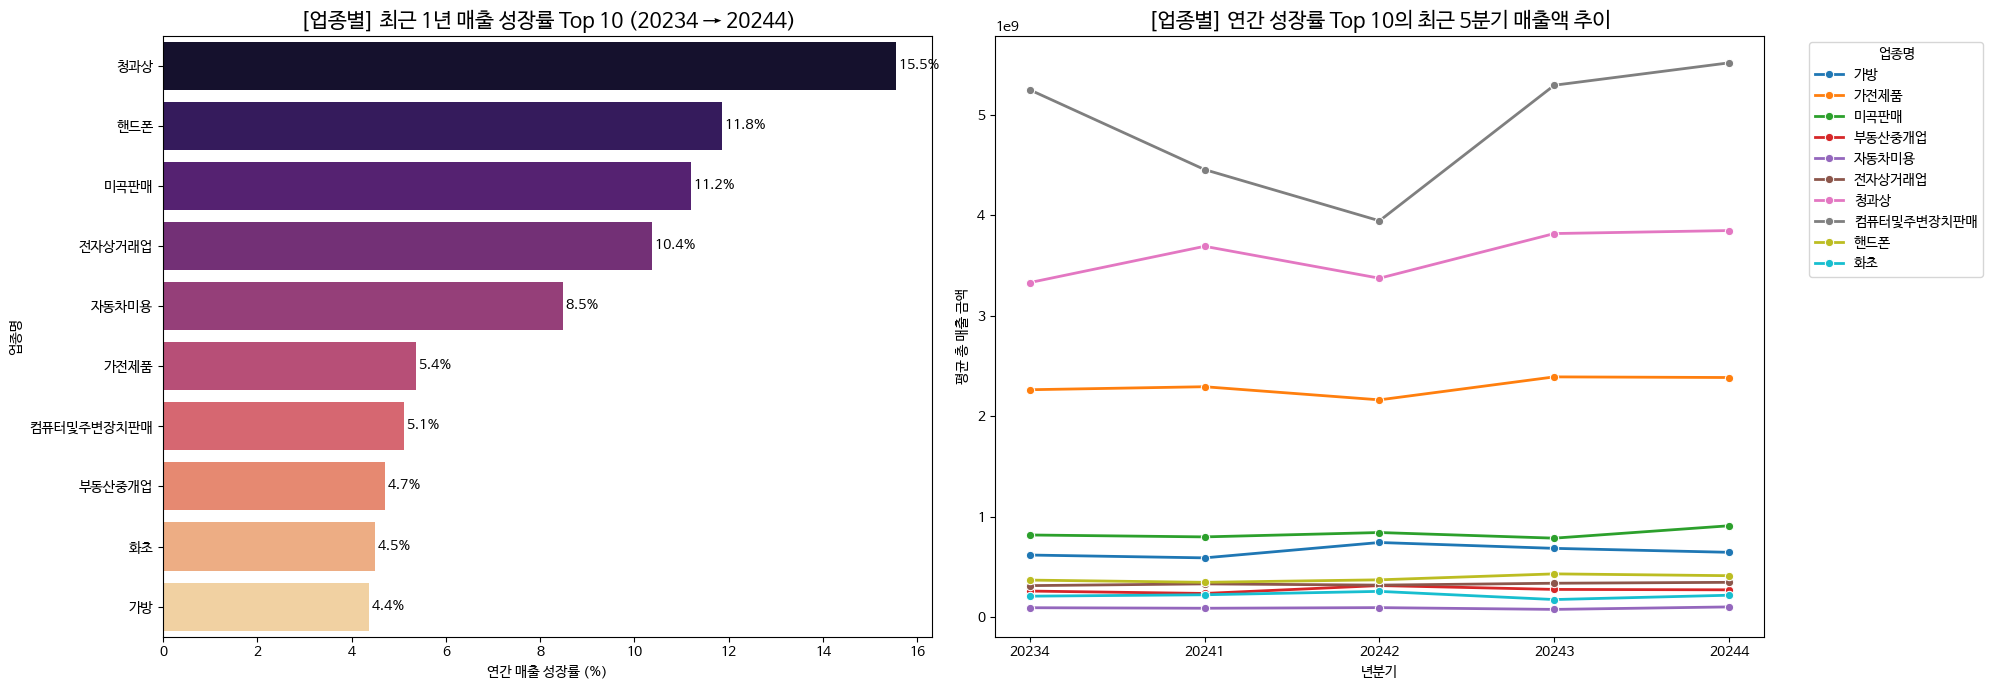

In [34]:
print("="*50)
print("3. 업종 단위 분석 시각화")
print("="*50)
plot_anual_trend(df, group_col='biz_nm', title_prefix='업종별', label_name='업종명')

요일/시간대 분석

1. 요일 및 시간대별 매출 집중도 (Top 10 상권 기준)




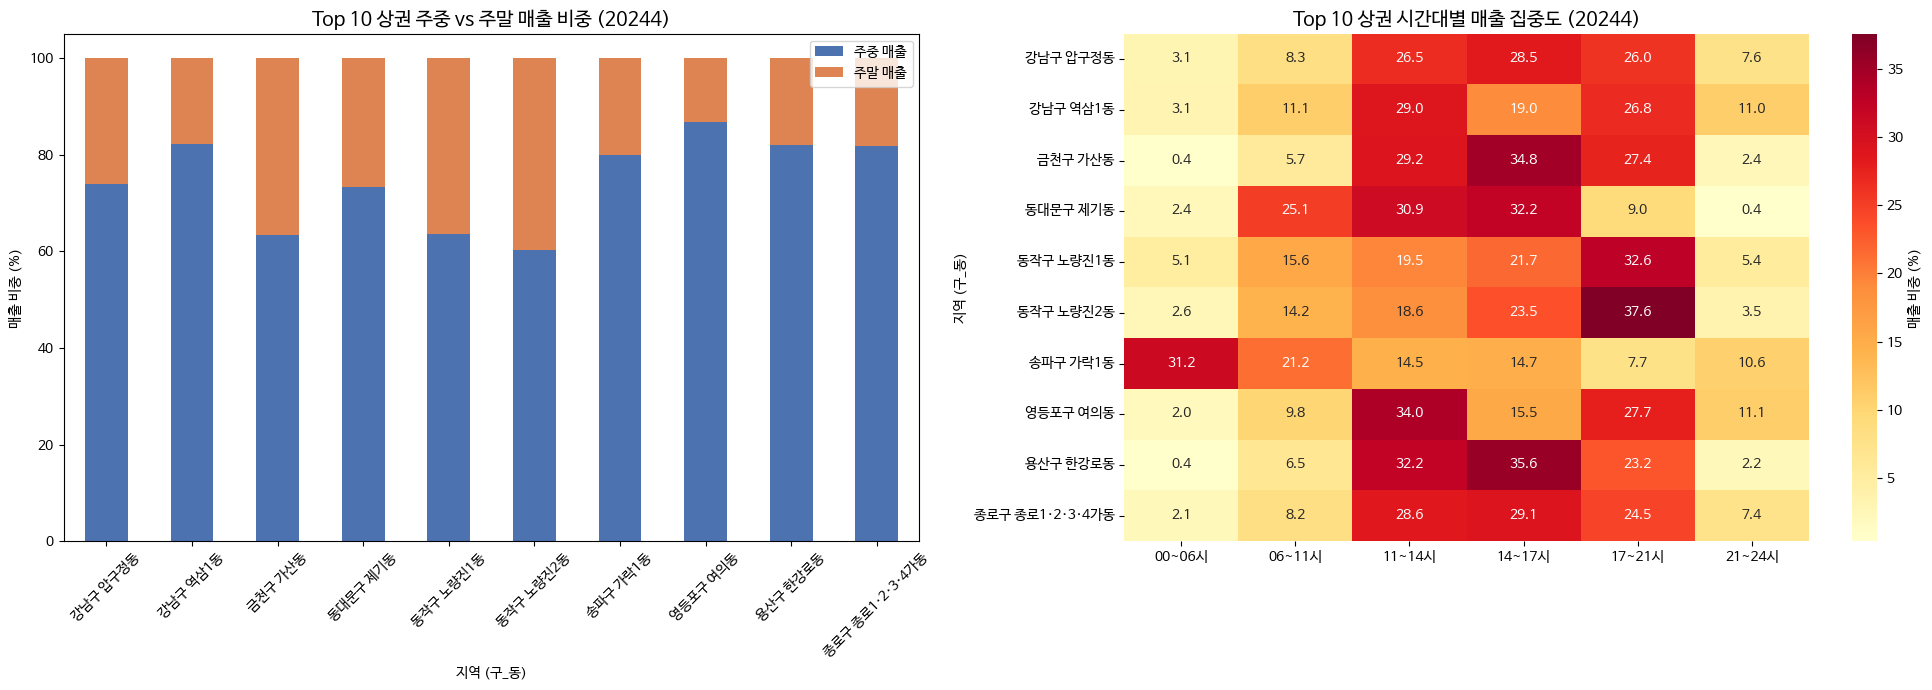

In [22]:
# 최신 분기 데이터만 추출 (현황 분석용)
latest_df = df[df['yq_cd'] == latest_q].copy()

# 최신 분기 기준 매출 총액 Top 10 지역 추출 (공통 사용)
top10_regions = latest_df.groupby('gu_dong')['sls_amt_tot'].mean().nlargest(10).index.tolist()
top10_df = latest_df[latest_df['gu_dong'].isin(top10_regions)]


print("1. 요일 및 시간대별 매출 집중도 (Top 10 상권 기준)")
print("\n")

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# 1-1. 주중 vs 주말 매출 비중 (누적 막대 그래프)
day_cols = ['sls_amt_wkdy', 'sls_amt_wknd']
day_data = top10_df.groupby('gu_dong')[day_cols].mean()
# 100% 비율로 변환
day_ratio = day_data.div(day_data.sum(axis=1), axis=0) * 100

day_ratio.plot(kind='bar', stacked=True, ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title(f'Top 10 상권 주중 vs 주말 매출 비중 ({latest_q})', fontsize=14)
axes[0].set_ylabel('매출 비중 (%)')
axes[0].set_xlabel('지역 (구_동)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['주중 매출', '주말 매출'], loc='upper right')

# 1-2. 시간대별 매출 집중도 (히트맵)
time_cols = ['sls_amt_0006', 'sls_amt_0611', 'sls_amt_1114', 'sls_amt_1417', 'sls_amt_1721', 'sls_amt_2124']
time_labels = ['00~06시', '06~11시', '11~14시', '14~17시', '17~21시', '21~24시']
time_data = top10_df.groupby('gu_dong')[time_cols].mean()

# 지역별로 시간대 비중(%) 구하기 (행별 정규화)
time_ratio = time_data.div(time_data.sum(axis=1), axis=0) * 100
time_ratio.columns = time_labels

sns.heatmap(time_ratio, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1], cbar_kws={'label': '매출 비중 (%)'})
axes[1].set_title(f'Top 10 상권 시간대별 매출 집중도 ({latest_q})', fontsize=14)
axes[1].set_ylabel('지역 (구_동)')

plt.tight_layout()
plt.show()

고객 프로파일링

2. 주 고객층 프로파일링: 연령대별 매출 비중




<Figure size 1200x600 with 0 Axes>

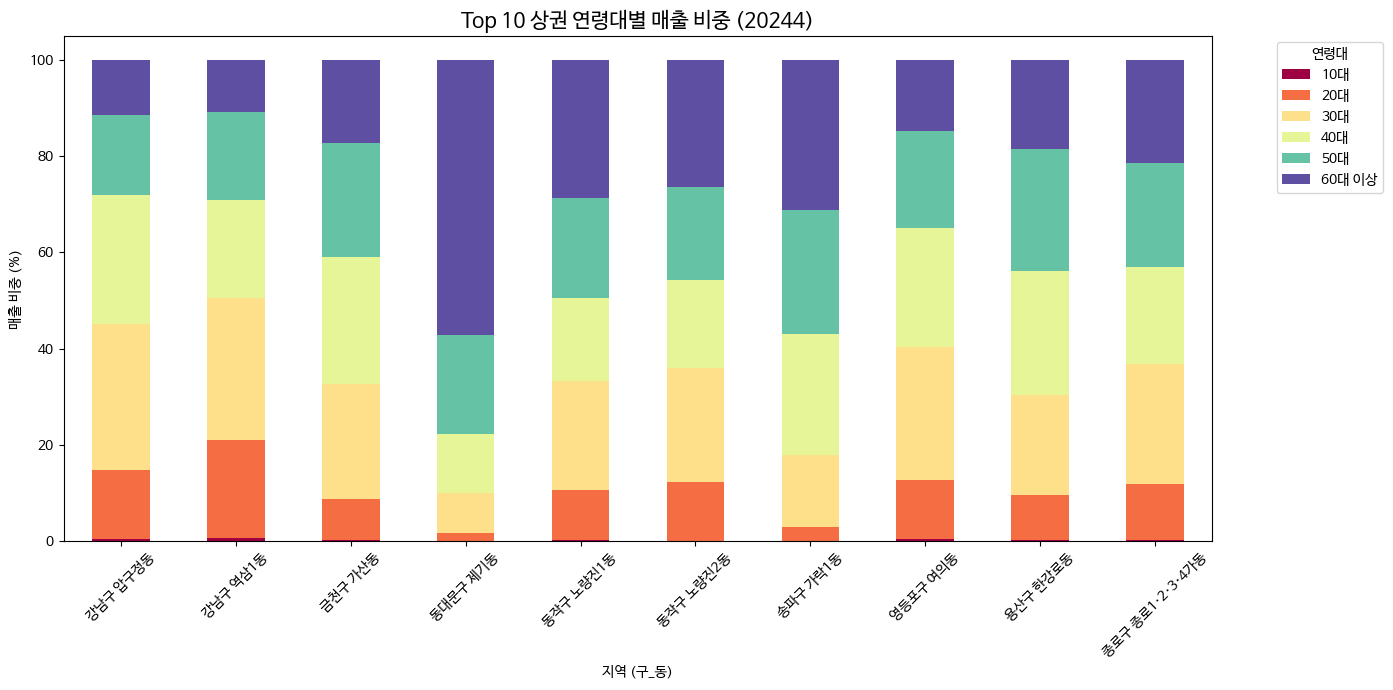

In [23]:
print("2. 주 고객층 프로파일링: 연령대별 매출 비중")
print("\n")

age_cols = ['sls_amt_10s', 'sls_amt_20s', 'sls_amt_30s', 'sls_amt_40s', 'sls_amt_50s', 'sls_amt_60s']
age_labels = ['10대', '20대', '30대', '40대', '50대', '60대 이상']

age_data = top10_df.groupby('gu_dong')[age_cols].mean()
# 100% 비율로 변환
age_ratio = age_data.div(age_data.sum(axis=1), axis=0) * 100
age_ratio.columns = age_labels

plt.figure(figsize=(12, 6))
age_ratio.plot(kind='bar', stacked=True, colormap='Spectral', figsize=(14, 7))
plt.title(f'Top 10 상권 연령대별 매출 비중 ({latest_q})', fontsize=15)
plt.ylabel('매출 비중 (%)')
plt.xlabel('지역 (구_동)')
plt.xticks(rotation=45)
plt.legend(title='연령대', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

개폐업률 리스크 분석

In [24]:
import plotly.express as px

print("3. 상권 활력도 및 리스크 분석 (개업률 vs 폐업률)")
print("\n")

# 1. 데이터 준비: 개폐업률, 총 매출 평균
risk_data = latest_df.groupby('gu_dong').agg({
    'open_rate': 'mean',
    'close_rate': 'mean',
    'sls_amt_tot': 'mean' # 매출 규모
}).dropna().reset_index()

# 기준선(평균) 계산
mean_open = risk_data['open_rate'].mean()
mean_close = risk_data['close_rate'].mean()

# 2. Plotly 인터랙티브 산점도 생성
fig = px.scatter(
    risk_data,
    x='close_rate',
    y='open_rate',
    size='sls_amt_tot',        # 점의 크기 = 해당 동의 총 매출
    hover_name='gu_dong',      # 마우스를 올리면 '구_동' 이름 표시
    hover_data={'open_rate': ':.2f', 'close_rate': ':.2f', 'sls_amt_tot': False}, # 말풍선 표시 내용
    labels={
        'close_rate': '폐업률 (%)',
        'open_rate': '개업률 (%)'
    },
    title=f'행정동별 개폐업률 리스크 산점도 - {latest_q}',
    opacity=0.6,
    color_discrete_sequence=['#8A2BE2'],
    size_max=45 # 가장 큰 점의 최대 크기
)

# 3. 평균 기준선 그리기
fig.add_hline(y=mean_open, line_dash="dash", line_color="blue",
              annotation_text="평균 개업률", annotation_position="top left")
fig.add_vline(x=mean_close, line_dash="dash", line_color="red",
              annotation_text="평균 폐업률", annotation_position="bottom right")

# 사분면 설명 텍스트
fig.add_annotation(x=risk_data['close_rate'].min(), y=risk_data['open_rate'].max(),
                   text="<b>안정 성장형 (저폐업/고개업)</b>", showarrow=False, font=dict(color="blue", size=13))
fig.add_annotation(x=risk_data['close_rate'].max(), y=risk_data['open_rate'].max(),
                   text="<b>고위험 고수익 (유행 민감형)</b>", showarrow=False, font=dict(color="red", size=13))

# 그래프 출력
fig.show()

3. 상권 활력도 및 리스크 분석 (개업률 vs 폐업률)




Step 5. '성장/유지/위축' 라벨링을 위한 증감률 기준선 찾기

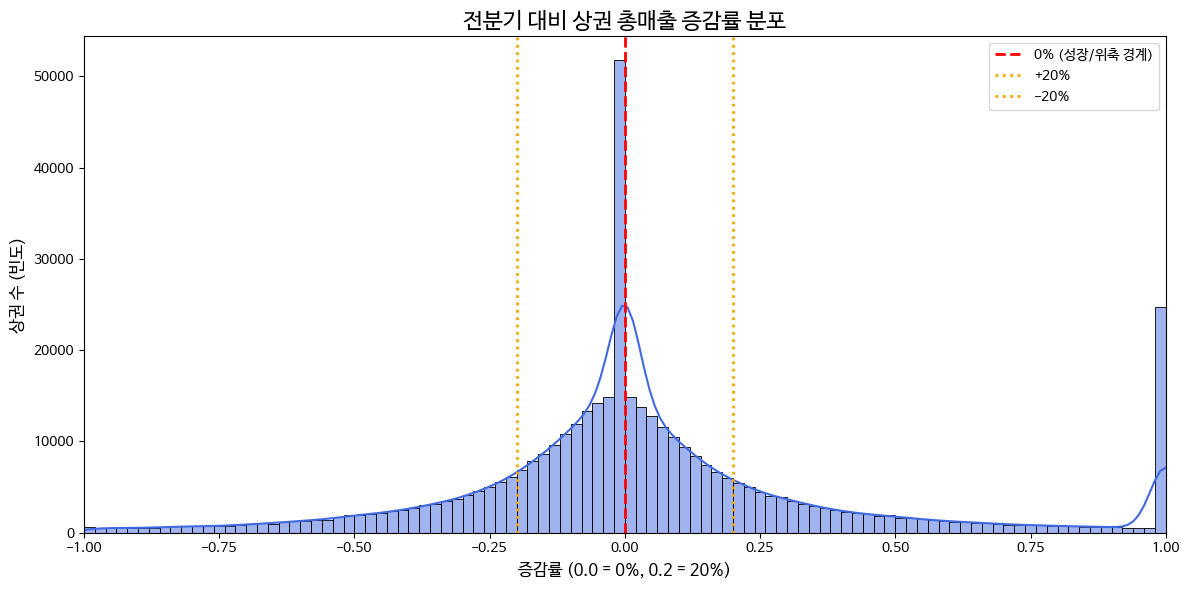

=== 매출 증감률 주요 통계량 ===
count    421316.000000
mean          3.121384
std         666.429409
min          -0.999998
10%          -0.342090
25%          -0.125212
50%           0.000000
75%           0.167010
90%           0.566842
max      371900.740525
Name: growth_rate, dtype: float64


In [35]:
# 경고문 무시
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 1. 데이터 정렬 및 복사 (SettingWithCopyWarning 방지)
df = df.sort_values(['dong_cd', 'biz_cd', 'yq_cd']).copy()

# 2. 전분기 대비 매출 증감률(growth_rate) 계산 - 타겟 변수
df['growth_rate'] = df.groupby(['dong_cd', 'biz_cd'])['sls_amt_tot'].pct_change()

# 3. 분석을 위한 데이터 정제 (무한대 값과 결측치 제거)
df['growth_rate'] = df['growth_rate'].replace([np.inf, -np.inf], np.nan)
growth_data = df.dropna(subset=['growth_rate'])['growth_rate']

# 4. 히스토그램 시각화 (극단적인 이상치를 제외하고 -100% ~ +100% 구간만 확대)
plt.figure(figsize=(12, 6))
# 데이터가 너무 많을 경우를 대비해 구간(bins)을 세밀하게 나눔
sns.histplot(growth_data.clip(-1, 1), bins=100, kde=True, color='royalblue')

# 기준선 표시 (0%)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='0% (성장/위축 경계)')
plt.axvline(x=0.2, color='orange', linestyle=':', linewidth=2, label='+20%')
plt.axvline(x=-0.2, color='orange', linestyle=':', linewidth=2, label='-20%')

plt.title("전분기 대비 상권 총매출 증감률 분포", fontsize=16)
plt.xlabel("증감률 (0.0 = 0%, 0.2 = 20%)", fontsize=12)
plt.ylabel("상권 수 (빈도)", fontsize=12)
plt.xlim(-1, 1)
plt.legend()
plt.tight_layout()
plt.show()

# 5. 주요 통계량 확인
print("=== 매출 증감률 주요 통계량 ===")
print(growth_data.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

타겟 변수 클래스 불균형 및 전이(Transition) 분석

=== 상권 변동성 클래스 분포 ===
target_class
0    17.789498
1    59.621519
2    22.588983
Name: proportion, dtype: float64


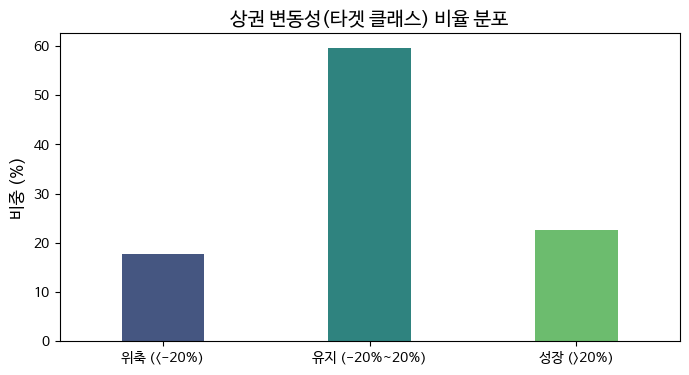


=== 분기 간 상권 상태 전이 확률 매트릭스 (%) ===


next_target_class,0,1,2
target_class,,,
0,14.38,34.30,51.32
1,11.43,73.25,15.32
2,37.99,44.73,17.29


In [36]:
# 1. ±20% 기준 라벨링 수행 (0: 위축, 1: 유지, 2: 성장)
df['target_class'] = pd.cut(
    df['growth_rate'],
    bins=[-np.inf, -0.2, 0.2, np.inf],
    labels=[0, 1, 2]
)

# 2. 클래스 불균형 확인 (비율)
class_counts = df['target_class'].value_counts(normalize=True).sort_index() * 100
print("=== 상권 변동성 클래스 분포 ===")
print(class_counts)

# 3. 시각화: 클래스별 비중 바플롯
plt.figure(figsize=(8, 4))
sns.barplot(x=['위축 (<-20%)', '유지 (-20%~20%)', '성장 (>20%)'], y=class_counts.values, palette='viridis', width=0.4)
plt.title("상권 변동성(타겟 클래스) 비율 분포", fontsize=14)
plt.ylabel("비중 (%)", fontsize=12)
plt.show()

# 4. 시계열 전이(Transition) 확인을 위해 다음 분기 타겟 생성 후 전이 매트릭스 계산
df['next_target_class'] = df.groupby(['dong_cd', 'biz_cd'])['target_class'].shift(-1)
transition_matrix = pd.crosstab(df['target_class'], df['next_target_class'], normalize='index') * 100

print("\n=== 분기 간 상권 상태 전이 확률 매트릭스 (%) ===")
display(transition_matrix.round(2))

테스트 데이터(2024년 4분기) 타겟 클래스 분포 확인

In [42]:
# 2024년 4분기 데이터만 필터링
df_q4 = df[df['yq_cd'] == 20244]

# Q4 타겟 클래스 분포 확인
q4_class_counts = df_q4['target_class'].value_counts(normalize=True).sort_index() * 100

print("=== 2024년 4분기(Test) 상권 변동성 클래스 분포 (%) ===")
print(q4_class_counts.round(2))

=== 2024년 4분기(Test) 상권 변동성 클래스 분포 (%) ===
target_class
0    14.83
1    64.70
2    20.46
Name: proportion, dtype: float64


## Feature Engineering

In [43]:
df_feat = df.copy()

# ==========================================
# [1] 기본 스케일 변수 (로그 변환)
# ==========================================
log_cols = ['sls_amt_tot', 'fl_pop_tot', 'wk_pop_tot', 'rs_pop_tot', 'apt_avg_price', 'fclty_subway_cnt', 'fclty_bus_stop_cnt']
for col in log_cols:
    df_feat[f'{col}_log'] = np.log1p(df_feat[col])

# ==========================================
# [2] 상권 경쟁력 및 효율 지표
# ==========================================
safe_store_cnt = df_feat['similar_store_cnt'].replace(0, 1)
df_feat['sls_per_store'] = df_feat['sls_amt_tot'] / safe_store_cnt
df_feat['store_density'] = df_feat['similar_store_cnt'] / df_feat['dong_area']

# ATV(객단가) 논리 수정: 매출 금액 / 매출 건수
safe_cnt_tot = df_feat['sls_cnt_tot'].replace(0, 1)
df_feat['ATV'] = (df_feat['sls_amt_tot'] / safe_cnt_tot).fillna(0)

# ==========================================
# [3] 상권 인구 영향력
# ==========================================
# 유동인구 대비 결제 전환율
df_feat['conversion_rate'] = df_feat['sls_cnt_tot'] / df_feat['fl_pop_tot']

# 상권 인구 비율
df_feat['total_pop'] = df_feat['fl_pop_tot'] + df_feat['wk_pop_tot'] + df_feat['rs_pop_tot']
df_feat['rs_pop_ratio'] = df_feat['rs_pop_tot'] / df_feat['total_pop']  # 상주인구 비중: 베드타운형
df_feat['wk_pop_ratio'] = df_feat['wk_pop_tot'] / df_feat['total_pop']  # 직장인구 비중: 오피스형

# ==========================================
# [4] 가구당 소비 여력
# ==========================================
df_feat['exp_per_hh'] = df_feat['exp_tot'] / df_feat['rs_hh_tot']    # 가구당 총 지출액
df_feat['exp_food_ratio'] = df_feat['exp_food'] / df_feat['exp_tot']    # 식료품 지출 비중(like 엥겔지수)

# ==========================================
# [5] 시간대/요일/연령대 비율
# ==========================================
safe_amt_tot = df_feat['sls_amt_tot'].replace(0, 1)

# 요일 비중
df_feat['sls_wkdy_ratio'] = df_feat['sls_amt_wkdy'] / safe_amt_tot
df_feat['sls_wknd_ratio'] = df_feat['sls_amt_wknd'] / safe_amt_tot

# 시간대 비중 (오타 수정 완료)
df_feat['sls_lunch_ratio'] = df_feat['sls_amt_1114'] / safe_amt_tot   # 점심
df_feat['sls_afternoon_ratio'] = df_feat['sls_amt_1417'] / safe_amt_tot   # 오후
df_feat['sls_evening_ratio'] = df_feat['sls_amt_1721'] / safe_amt_tot   # 저녁 (퇴근/회식)
df_feat['sls_night_ratio'] = df_feat['sls_amt_2124'] / safe_amt_tot   # 심야 (유흥)

# 연령대 비중
df_feat['sls_2030s_ratio'] = (df_feat['sls_amt_20s'] + df_feat['sls_amt_30s']) / safe_amt_tot
df_feat['sls_3050s_ratio'] = (df_feat['sls_amt_30s'] + df_feat['sls_amt_40s'] + df_feat['sls_amt_50s']) / safe_amt_tot
df_feat['sls_60s_ratio'] = df_feat['sls_amt_60s'] / safe_amt_tot

# ==========================================
# [6] 인프라 지표
# ==========================================
df_feat['is_univ'] = (df_feat['fclty_univ_cnt'] > 0).astype(int)
df_feat['is_arpt'] = (df_feat['fclty_arpt_cnt'] > 0).astype(int)
df_feat['edu_cnt'] = df_feat['fclty_kind_cnt'] + df_feat['fclty_elem_cnt'] + df_feat['fclty_mid_cnt'] + df_feat['fclty_high_cnt']
df_feat['traffic_score'] = (df_feat['fclty_subway_cnt_log'] * 3) + df_feat['fclty_bus_stop_cnt_log']

# ==========================================
# [7] 프랜차이즈 침투율
# ==========================================
df_feat['franchise_ratio'] = df_feat['franchise_cnt'] / safe_store_cnt    # 상권 안정성 지표

In [44]:
df_feat.head(5)

,dong_cd,biz_cd,dong_nm,biz_nm,yq_cd,ds,year,quarter,gu_cd,gu_nm,...,sls_evening_ratio,sls_night_ratio,sls_2030s_ratio,sls_3050s_ratio,sls_60s_ratio,is_univ,is_arpt,edu_cnt,traffic_score,franchise_ratio
0,11110515,CS100001,청운효자동,한식음식점,20191,2019-01-01,2019.0,1.0,11110.0,종로구,...,0.339677,0.161194,0.318089,0.528391,0.081971,1,0,6.0,3.295837,0.012500
1,11110515,CS100001,청운효자동,한식음식점,20192,2019-04-01,2019.0,2.0,11110.0,종로구,...,0.342767,0.150563,0.319993,0.525832,0.107766,1,0,6.0,3.295837,0.012658
2,11110515,CS100001,청운효자동,한식음식점,20193,2019-07-01,2019.0,3.0,11110.0,종로구,...,0.346854,0.147596,0.323724,0.515234,0.116989,1,0,6.0,3.295837,0.013158
3,11110515,CS100001,청운효자동,한식음식점,20194,2019-10-01,2019.0,4.0,11110.0,종로구,...,0.370518,0.147147,0.317732,0.480645,0.112008,1,0,6.0,3.295837,0.012658
4,11110515,CS100001,청운효자동,한식음식점,20201,2020-01-01,2020.0,1.0,11110.0,종로구,...,0.357403,0.142621,0.341881,0.529797,0.109664,1,0,6.0,3.295837,0.013333


In [45]:
# ==========================================
# [8] 시계열 파생 변수 생성
# ==========================================
df_feat = df_feat.sort_values(by=['dong_cd', 'biz_cd', 'yq_cd']).reset_index(drop=True)

target_cols = ['sls_amt_tot_log', 'sls_per_store', 'ATV', 'fl_pop_tot_log', 'store_density']

grouped = df_feat.groupby(['dong_cd', 'biz_cd'])

for col in target_cols:
    df_feat[f'{col}_MA2'] = grouped[col].transform(lambda x: x.rolling(window=2, min_periods=1).mean())
    df_feat[f'{col}_STD2'] = grouped[col].transform(lambda x: x.rolling(window=2, min_periods=2).std()).fillna(0)

    df_feat[f'{col}_MA4'] = grouped[col].transform(lambda x: x.rolling(window=4, min_periods=1).mean())
    df_feat[f'{col}_STD4'] = grouped[col].transform(lambda x: x.rolling(window=4, min_periods=2).std()).fillna(0)

    df_feat[f'{col}_QoQ'] = grouped[col].transform(lambda x: (x - x.shift(1)) / (x.shift(1) + 1e-5)).fillna(0)

In [46]:
display(df_feat[['dong_cd', 'biz_cd', 'yq_cd', 'ATV', 'ATV_MA2', 'ATV_MA4', 'ATV_QoQ']].head())

,dong_cd,biz_cd,yq_cd,ATV,ATV_MA2,ATV_MA4,ATV_QoQ
0,11110515,CS100001,20191,29288.696246,29288.696246,29288.696246,0.000000
1,11110515,CS100001,20192,27924.413127,28606.554687,28606.554687,-0.046581
2,11110515,CS100001,20193,27091.115348,27507.764238,28101.408241,-0.029841
3,11110515,CS100001,20194,30659.810868,28875.463108,28741.008897,0.131729
4,11110515,CS100001,20201,29206.011081,29932.910975,28720.337606,-0.047417


군집 분석

In [47]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==========================================
# [9] 상권 특성 클러스터링 (K-Means) - 데이터 누수 방지 적용
# ==========================================
cluster_features = [
    # 1. 소비 패턴
    'sls_wknd_ratio',
    'sls_lunch_ratio',
    'sls_evening_ratio',
    'sls_night_ratio',
    'sls_2030s_ratio',
    'ATV',

    # 2. 입지 특성
    'wk_pop_tot_log',
    'rs_pop_tot_log',

    # 3. 상권 구조
    'franchise_ratio'
]

# 2024년 4분기 이전 데이터 중, 매출이 실제로 존재하는(ATV > 0) 정상 영업 데이터만 필터링
train_threshold = 20244
valid_mask = (df_feat['ATV'] > 0) & (df_feat['yq_cd'] < train_threshold)
df_train_valid = df_feat[valid_mask].copy()

# 스케일링 및 K-Means 학습
scaler = StandardScaler()
scaled_train = scaler.fit_transform(df_train_valid[cluster_features])

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(scaled_train)

# 전체 데이터에 클러스터 라벨 매핑
# 전체를 우선 -1(휴면/결측 상권)로 세팅
df_feat['cluster_id'] = -1

# 매출이 있는(ATV > 0) 전체 분기 데이터에 대해서만 예측 적용
all_valid_mask = df_feat['ATV'] > 0
scaled_all_valid = scaler.transform(df_feat.loc[all_valid_mask, cluster_features])
df_feat.loc[all_valid_mask, 'cluster_id'] = kmeans.predict(scaled_all_valid)

# 결과 프로파일링 (사후 분석)
print("=== 클러스터별 데이터 수 ===")
print(df_feat['cluster_id'].value_counts().sort_index())

print("\n=== 클러스터별 주요 피처 평균값 ===")
cluster_means = df_feat[df_feat['cluster_id'] != -1].groupby('cluster_id')[cluster_features].mean()

display(cluster_means.round(3))

=== 클러스터별 데이터 수 ===
cluster_id
-1     55819
 0     40436
 1    177006
 2     44148
 3    146631
Name: count, dtype: int64

=== 클러스터별 주요 피처 평균값 ===


,sls_wknd_ratio,sls_lunch_ratio,sls_evening_ratio,sls_night_ratio,sls_2030s_ratio,ATV,wk_pop_tot_log,rs_pop_tot_log,franchise_ratio
cluster_id,,,,,,,,,
0,0.297,0.165,0.365,0.173,0.414,19009.359,7.766,9.973,0.593
1,0.260,0.200,0.411,0.051,0.307,104711.337,7.842,10.027,0.078
2,0.318,0.057,0.291,0.352,0.396,67594.797,8.098,9.942,0.063
3,0.151,0.336,0.167,0.010,0.179,147546.985,8.234,9.918,0.037


In [48]:
df_feat[(df_grid['dong_cd'] == 11110515) & (df_grid['biz_cd'] == 'CS100001')][['yq_cd', 'cluster_id'] + cluster_features]

,yq_cd,cluster_id,sls_wknd_ratio,sls_lunch_ratio,sls_evening_ratio,sls_night_ratio,sls_2030s_ratio,ATV,wk_pop_tot_log,rs_pop_tot_log,franchise_ratio
0,20191,1,0.216310,0.341954,0.339677,0.161194,0.318089,29288.696246,8.776013,9.476390,0.012500
1,20192,1,0.223332,0.357197,0.342767,0.150563,0.319993,27924.413127,8.776013,9.475086,0.012658
2,20193,1,0.228629,0.362353,0.346854,0.147596,0.323724,27091.115348,8.776013,9.475086,0.013158
3,20194,1,0.234082,0.304598,0.370518,0.147147,0.317732,30659.810868,8.776013,9.458606,0.012658
4,20201,1,0.234339,0.315146,0.357403,0.142621,0.341881,29206.011081,8.776013,9.458606,0.013333
5,20202,1,0.224085,0.357173,0.362305,0.111741,0.350774,27284.679515,8.776013,9.458606,0.013333
6,20203,1,0.224694,0.358973,0.369942,0.106035,0.346105,27838.345788,8.776013,9.458606,0.013158
7,20204,1,0.247701,0.371274,0.366554,0.082618,0.341173,26991.226921,8.740817,9.428270,0.013333
8,20211,1,0.247062,0.369296,0.408108,0.062688,0.298147,30093.967528,8.740817,9.428270,0.013333
9,20212,1,0.245222,0.365927,0.386875,0.101384,0.326465,29932.378280,8.740817,9.428270,0.014493


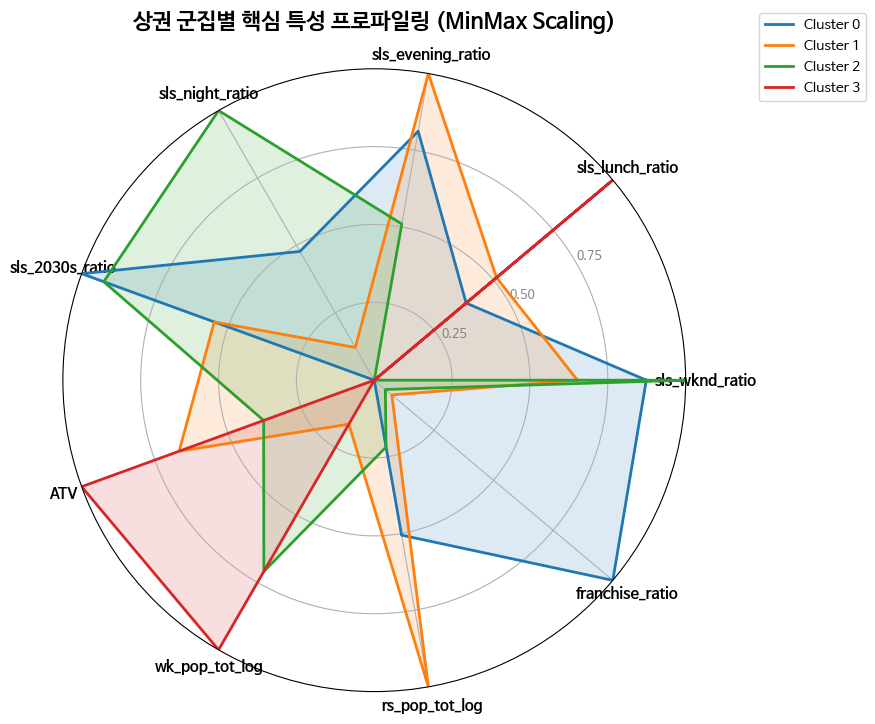

In [49]:
from sklearn.preprocessing import MinMaxScaler
from math import pi

# 1. 한글 폰트 설정 (기존 설정 유지)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 레이더 차트에 그릴 핵심 피처 선정
# 상권의 공간적 특성과 소비 패턴을 명확히 보여주는 변수들로 구성
radar_features = [
    'sls_wknd_ratio',
    'sls_lunch_ratio',
    'sls_evening_ratio',
    'sls_night_ratio',
    'sls_2030s_ratio',
    'ATV',

    'wk_pop_tot_log',
    'rs_pop_tot_log',

    'franchise_ratio'
]

# 유효한 군집 데이터에서 평균값 추출
cluster_radar_data = df_feat[df_feat['cluster_id'] != -1].groupby('cluster_id')[radar_features].mean()

# 3. 데이터 스케일링 (0 ~ 1)
# 각 변수별로 가장 큰 값을 바깥쪽(1), 가장 작은 값을 안쪽(0)으로 변환
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(cluster_radar_data)
scaled_df = pd.DataFrame(scaled_data, columns=radar_features, index=cluster_radar_data.index)

# 4. 차트를 그릴 각도(Angles) 계산
N = len(radar_features)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # 다각형을 닫기 위해 첫 번째 각도를 맨 끝에 추가

# 5. 시각화 세팅
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('white')

# 군집별 색상 매핑
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
cluster_labels = [f'Cluster {i}' for i in scaled_df.index]

# 6. 군집별로 레이더 차트 그리기
for i, row in enumerate(scaled_df.itertuples(index=False)):
    values = list(row)
    values += values[:1]  # 다각형을 닫기 위해 첫 번째 값을 맨 끝에 추가

    # 테두리 선 그리기
    ax.plot(angles, values, color=colors[i], linewidth=2, linestyle='solid', label=cluster_labels[i])
    # 내부 색상 채우기
    ax.fill(angles, values, color=colors[i], alpha=0.15)

# 7. 축 및 라벨 디자인
# 각도별 이름 지정
plt.xticks(angles[:-1], radar_features, size=11, color='black', weight='bold')

# y축(방사형) 눈금 설정
ax.set_rlabel_position(30)
plt.yticks([0.25, 0.5, 0.75], ["0.25", "0.50", "0.75"], color="grey", size=9)
plt.ylim(0, 1)

# 차트 제목 및 범례 추가
plt.title('상권 군집별 핵심 특성 프로파일링 (MinMax Scaling)', size=16, weight='bold', pad=30)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.show()

In [50]:
print(df_feat.columns.tolist())

['dong_cd', 'biz_cd', 'dong_nm', 'biz_nm', 'yq_cd', 'ds', 'year', 'quarter', 'gu_cd', 'gu_nm', 'store_cnt', 'similar_store_cnt', 'open_rate', 'open_store_cnt', 'close_rate', 'close_store_cnt', 'franchise_cnt', 'sls_amt_tot', 'sls_cnt_tot', 'sls_amt_wkdy', 'sls_amt_wknd', 'sls_amt_mon', 'sls_amt_tue', 'sls_amt_wed', 'sls_amt_thu', 'sls_amt_fri', 'sls_amt_sat', 'sls_amt_sun', 'sls_amt_0006', 'sls_amt_0611', 'sls_amt_1114', 'sls_amt_1417', 'sls_amt_1721', 'sls_amt_2124', 'sls_amt_m', 'sls_amt_f', 'sls_amt_10s', 'sls_amt_20s', 'sls_amt_30s', 'sls_amt_40s', 'sls_amt_50s', 'sls_amt_60s', 'sls_cnt_wkdy', 'sls_cnt_wknd', 'sls_cnt_mon', 'sls_cnt_tue', 'sls_cnt_wed', 'sls_cnt_thu', 'sls_cnt_fri', 'sls_cnt_sat', 'sls_cnt_sun', 'sls_cnt_0006', 'sls_cnt_0611', 'sls_cnt_1114', 'sls_cnt_1417', 'sls_cnt_1721', 'sls_cnt_2124', 'sls_cnt_m', 'sls_cnt_f', 'sls_cnt_10s', 'sls_cnt_20s', 'sls_cnt_30s', 'sls_cnt_40s', 'sls_cnt_50s', 'sls_cnt_60s', 'fl_pop_tot', 'fl_pop_m', 'fl_pop_f', 'fl_pop_10s', 'fl_pop_20

In [51]:
# ==========================================
# [10] 모델에 넣을 임시 피처 리스트 생성
# ==========================================

# 1. 식별자 및 기준 변수
id_features = [
    'yq_cd', 'dong_cd', 'biz_cd'
]

# 2. 상권 규모 및 인프라 (Log 변환 및 점수화 변수)
scale_infra_features = [
    'sls_amt_tot_log', 'fl_pop_tot_log', 'wk_pop_tot_log', 'rs_pop_tot_log',
    'apt_avg_price_log', 'is_univ', 'is_arpt', 'edu_cnt', 'traffic_score'
]

# 3. 상권 효율성 및 경쟁력 지표
efficiency_features = [
    'sls_per_store', 'store_density', 'ATV',
    'conversion_rate',
    'franchise_ratio'
]

# 4. 배후 인구 및 소비 여력 특성
demographic_features = [
    'rs_pop_ratio',
    'wk_pop_ratio',
    'exp_per_hh',
    'exp_food_ratio'
]

# 5. 매출 발생 패턴 (시간/요일/연령)
pattern_features = [
    'sls_wkdy_ratio', 'sls_wknd_ratio',
    'sls_lunch_ratio', 'sls_afternoon_ratio', 'sls_evening_ratio', 'sls_night_ratio',
    'sls_2030s_ratio', 'sls_3050s_ratio', 'sls_60s_ratio',
]

# 6. 시계열 모멘텀 및 변동성 지표 (MA, STD, QoQ)
ts_features = [
    'sls_amt_tot_log_MA2', 'sls_amt_tot_log_STD2', 'sls_amt_tot_log_MA4', 'sls_amt_tot_log_STD4', 'sls_amt_tot_log_QoQ',
    'sls_per_store_MA2', 'sls_per_store_STD2', 'sls_per_store_MA4', 'sls_per_store_STD4', 'sls_per_store_QoQ',
    'ATV_MA2', 'ATV_STD2', 'ATV_MA4', 'ATV_STD4', 'ATV_QoQ',
    'fl_pop_tot_log_MA2', 'fl_pop_tot_log_STD2', 'fl_pop_tot_log_MA4', 'fl_pop_tot_log_STD4', 'fl_pop_tot_log_QoQ',
    'store_density_MA2', 'store_density_STD2', 'store_density_MA4', 'store_density_STD4', 'store_density_QoQ'
]

# 7. 상권 유형
cluster_features = ['cluster_id']

final_features = id_features + scale_infra_features + efficiency_features + demographic_features + pattern_features + ts_features + cluster_features
df_final = df_feat[final_features].copy()

print("=== 피처 엔지니어링 & 클러스터링 완료 ===")
print("총 피처 개수:", len(final_features) - 3) # 식별자 3개 제외

=== 피처 엔지니어링 & 클러스터링 완료 ===
총 피처 개수: 53


## Sliding Window (과거 데이터 시프트)

 t 분기의 타겟(성장/유지/위축)을 예측하기 위해, 모델의 입력(Input) 피처들은 전부
 분기(또는 그 이전)의 데이터를 바라보도록 짝을 맞춰주는 작업

In [52]:
# 1. 데이터 정렬 (누수 방지의 핵심)
df_feat = df_feat.sort_values(['dong_cd', 'biz_cd', 'yq_cd']).reset_index(drop=True)
df_final = df_final.sort_values(['dong_cd', 'biz_cd', 'yq_cd']).reset_index(drop=True)

# 2. 타겟(Target) 생성 (원본 데이터인 df_feat에서 계산하여 df_final에 부여)
df_feat['growth_rate'] = df_feat.groupby(['dong_cd', 'biz_cd'])['sls_amt_tot'].pct_change()
df_feat['growth_rate'] = df_feat['growth_rate'].replace([np.inf, -np.inf], np.nan)

# ±20% 기준으로 위축(0), 유지(1), 성장(2) 라벨링
df_final['target_class'] = pd.cut(
    df_feat['growth_rate'],
    bins=[-np.inf, -0.2, 0.2, np.inf],
    labels=[0, 1, 2]
)

# 3. Shift(한 칸 밀기)를 적용할 피처 리스트 뽑기
shift_cols = [col for col in df_final.columns if col not in ['yq_cd', 'dong_cd', 'biz_cd', 'target_class']]

# 4. Sliding Window (Shift) 적용
df_shifted = df_final.copy()
for col in shift_cols:
    df_shifted[f'prev_{col}'] = df_shifted.groupby(['dong_cd', 'biz_cd'])[col].shift(1)

# 5. 변수 선택 이전 임시 데이터셋 조립
temp_cols = ['dong_cd', 'biz_cd', 'yq_cd', 'target_class'] + [f'prev_{col}' for col in shift_cols]
df_temp = df_shifted[temp_cols].copy()

# 6. 결측치 제거
df_temp = df_temp.dropna().reset_index(drop=True)

print("=== 임시 데이터셋 (df_temp) 완성 ===")
print("데이터 쉐이프:", df_temp.shape)
print("\n[Target 클래스 비율 확인 (위축:0, 유지:1, 성장:2)]")
print(df_temp['target_class'].value_counts(normalize=True).sort_index() * 100)

=== 임시 데이터셋 (df_temp) 완성 ===
데이터 쉐이프: (391350, 57)

[Target 클래스 비율 확인 (위축:0, 유지:1, 성장:2)]
target_class
0    18.710873
1    57.417657
2    23.871471
Name: proportion, dtype: float64


In [53]:
df_temp.columns.tolist()

['dong_cd',
 'biz_cd',
 'yq_cd',
 'target_class',
 'prev_sls_amt_tot_log',
 'prev_fl_pop_tot_log',
 'prev_wk_pop_tot_log',
 'prev_rs_pop_tot_log',
 'prev_apt_avg_price_log',
 'prev_is_univ',
 'prev_is_arpt',
 'prev_edu_cnt',
 'prev_traffic_score',
 'prev_sls_per_store',
 'prev_store_density',
 'prev_ATV',
 'prev_conversion_rate',
 'prev_franchise_ratio',
 'prev_rs_pop_ratio',
 'prev_wk_pop_ratio',
 'prev_exp_per_hh',
 'prev_exp_food_ratio',
 'prev_sls_wkdy_ratio',
 'prev_sls_wknd_ratio',
 'prev_sls_lunch_ratio',
 'prev_sls_afternoon_ratio',
 'prev_sls_evening_ratio',
 'prev_sls_night_ratio',
 'prev_sls_2030s_ratio',
 'prev_sls_3050s_ratio',
 'prev_sls_60s_ratio',
 'prev_sls_amt_tot_log_MA2',
 'prev_sls_amt_tot_log_STD2',
 'prev_sls_amt_tot_log_MA4',
 'prev_sls_amt_tot_log_STD4',
 'prev_sls_amt_tot_log_QoQ',
 'prev_sls_per_store_MA2',
 'prev_sls_per_store_STD2',
 'prev_sls_per_store_MA4',
 'prev_sls_per_store_STD4',
 'prev_sls_per_store_QoQ',
 'prev_ATV_MA2',
 'prev_ATV_STD2',
 'prev_AT

## 탐색적 가설 검정

In [54]:
from scipy import stats

# 1. Train / Val / Test 시간순 분할
df_train = df_temp[df_temp['yq_cd'] <= 20242].copy()

print(f"Train 셋 Shape: {df_train.shape} (기한: ~2024년 2분기)")
print("-" * 50)


# 2. 피처 그룹핑
target_col = 'target_class'

# 범주형 피처 리스트
cat_features = ['prev_is_univ', 'prev_is_arpt', 'prev_cluster_id']

# 연속형 피처 리스트 자동 추출 (식별자, 타겟, 범주형 제외)
exclude_cols = ['dong_cd', 'biz_cd', 'yq_cd', target_col] + cat_features
num_features = [col for col in df_train.columns if col not in exclude_cols]


# 3. 가설 검정 (★ 오직 Train 데이터로만 수행 ★ - 데이터 누수 방지)
results = []

# 3-1. 연속형 변수 검정 (ANOVA)
for col in num_features:
    # df_train에 컬럼이 있고 결측치가 모두 제거된 상태인지 확인
    if col in df_train.columns:
        # 타겟 클래스(0, 1, 2)별로 그룹 데이터 추출
        groups = [df_train[df_train[target_col] == cls][col].dropna() for cls in df_train[target_col].dropna().unique()]

        # 각 클래스별 데이터가 충분히 있는지 확인 후 검정
        if len(groups) > 1 and all(len(g) > 0 for g in groups):
            f_stat, p_val = stats.f_oneway(*groups)
            results.append({'Feature': col, 'Type': 'Numeric (ANOVA)', 'p-value': p_val, 'Significant': p_val < 0.05})

# 3-2. 범주형 변수 검정 (Chi-Square)
for col in cat_features:
    if col in df_train.columns:
        # 교차표 생성
        contingency_table = pd.crosstab(df_train[target_col], df_train[col])
        chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
        results.append({'Feature': col, 'Type': 'Categorical (Chi-Square)', 'p-value': p_val, 'Significant': p_val < 0.05})


# 4. 결과 정리 및 유의미한 피처 선정
df_test_results = pd.DataFrame(results)
df_test_results['p-value_disp'] = df_test_results['p-value'].apply(lambda x: f"{x:.4f}" if not pd.isna(x) else "NaN")

print("\n=== 피처별 가설 검정 결과 (Train 데이터 기준) ===")
display(df_test_results[['Feature', 'Type', 'p-value_disp', 'Significant']].sort_values(
    by=['Significant', 'Type'], ascending=[False, True]
).reset_index(drop=True))

passed_features = df_test_results[df_test_results['Significant'] == True]['Feature'].tolist()
failed_features = df_test_results[df_test_results['Significant'] == False]['Feature'].tolist()

print(f"\n✅ 통과된 피처 (모델 학습 후보): {len(passed_features)}개")
print(passed_features)
print(f"❌ 탈락된 피처 (통계적 의미 없음): {len(failed_features)}개")
print(failed_features)

Train 셋 Shape: (357365, 57) (기한: ~2024년 2분기)
--------------------------------------------------

=== 피처별 가설 검정 결과 (Train 데이터 기준) ===


,Feature,Type,p-value_disp,Significant
0,prev_cluster_id,Categorical (Chi-Square),0.0000,True
1,prev_sls_amt_tot_log,Numeric (ANOVA),0.0000,True
2,prev_fl_pop_tot_log,Numeric (ANOVA),0.0000,True
3,prev_wk_pop_tot_log,Numeric (ANOVA),0.0000,True
4,prev_rs_pop_tot_log,Numeric (ANOVA),0.0000,True
5,prev_apt_avg_price_log,Numeric (ANOVA),0.0000,True
6,prev_edu_cnt,Numeric (ANOVA),0.0000,True
7,prev_traffic_score,Numeric (ANOVA),0.0000,True
8,prev_sls_per_store,Numeric (ANOVA),0.0000,True
9,prev_store_density,Numeric (ANOVA),0.0000,True



✅ 통과된 피처 (모델 학습 후보): 49개
['prev_sls_amt_tot_log', 'prev_fl_pop_tot_log', 'prev_wk_pop_tot_log', 'prev_rs_pop_tot_log', 'prev_apt_avg_price_log', 'prev_edu_cnt', 'prev_traffic_score', 'prev_sls_per_store', 'prev_store_density', 'prev_ATV', 'prev_conversion_rate', 'prev_franchise_ratio', 'prev_rs_pop_ratio', 'prev_wk_pop_ratio', 'prev_exp_food_ratio', 'prev_sls_wkdy_ratio', 'prev_sls_wknd_ratio', 'prev_sls_lunch_ratio', 'prev_sls_afternoon_ratio', 'prev_sls_evening_ratio', 'prev_sls_night_ratio', 'prev_sls_2030s_ratio', 'prev_sls_3050s_ratio', 'prev_sls_60s_ratio', 'prev_sls_amt_tot_log_MA2', 'prev_sls_amt_tot_log_STD2', 'prev_sls_amt_tot_log_MA4', 'prev_sls_amt_tot_log_STD4', 'prev_sls_amt_tot_log_QoQ', 'prev_sls_per_store_MA2', 'prev_sls_per_store_STD2', 'prev_sls_per_store_MA4', 'prev_sls_per_store_STD4', 'prev_ATV_MA2', 'prev_ATV_STD2', 'prev_ATV_MA4', 'prev_ATV_STD4', 'prev_ATV_QoQ', 'prev_fl_pop_tot_log_MA2', 'prev_fl_pop_tot_log_STD2', 'prev_fl_pop_tot_log_MA4', 'prev_fl_pop_tot_

## VIF(다중공선성) 검사

=== VIF(분산팽창지수) 계산 결과 ===


,Feature,VIF
0,prev_sls_wknd_ratio,1.887570e+10
1,prev_sls_wkdy_ratio,1.332432e+10
2,prev_fl_pop_tot_log,2.743451e+05
3,prev_fl_pop_tot_log_MA2,2.719288e+05
4,prev_store_density_MA2,9.290302e+04
5,prev_store_density,1.318726e+04
6,prev_store_density_MA4,9.412993e+03
7,prev_sls_amt_tot_log_MA2,1.321281e+03
8,prev_sls_amt_tot_log,1.201462e+03
9,prev_fl_pop_tot_log_MA4,5.206995e+02


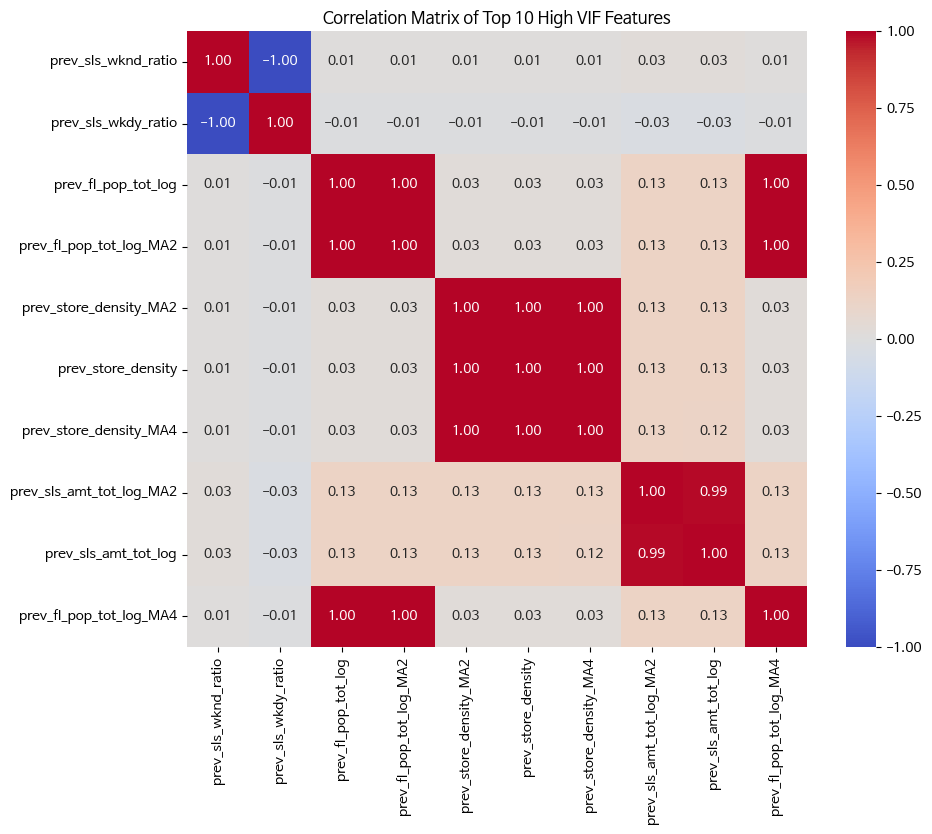

In [55]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. ANOVA/Chi-Square 통과한 피처들만 선택 (passed_features)
X_vif = df_train[passed_features].copy()

# 2. VIF 계산을 위한 전처리
# VIF는 연속형 변수에 대해서만 계산하므로, 범주형 변수(cluster_id 등)가 섞여있다면 제외해야 함
# 데이터 타입이 숫자형인 것만 필터링하고 결측치 제거
vif_numeric_cols = [col for col in X_vif.columns if col != 'prev_cluster_id']
X_vif_numeric = X_vif[vif_numeric_cols].select_dtypes(include=[np.number]).dropna()

# statsmodels VIF 계산을 위해 상수항(Intercept) 추가 필수
X_vif_numeric.insert(0, 'const', 1.0)

# 3. VIF 계산
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_numeric.values, i) for i in range(X_vif_numeric.shape[1])]

# 4. 결과 출력 (상수항 제외, VIF 높은 순 정렬)
vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False).reset_index(drop=True)

print("=== VIF(분산팽창지수) 계산 결과 ===")
display(vif_data.head(20)) # 너무 많을 수 있으니 상위 20개만 먼저 확인

# 5. 상관행렬 시각화 (VIF가 높은 상위 10개 변수 간의 관계 파악)
top_10_vif_features = vif_data['Feature'].head(10).tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(X_vif_numeric[top_10_vif_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Top 10 High VIF Features")
plt.show()

VIF 2차 검사

=== VIF(분산팽창지수) 계산 결과 ===


,Feature,VIF
0,prev_fl_pop_tot_log,271175.695320
1,prev_fl_pop_tot_log_MA2,270741.773395
2,prev_store_density,32932.464481
3,prev_store_density_MA2,32853.517019
4,prev_sls_amt_tot_log,1185.305760
5,prev_sls_amt_tot_log_MA2,1160.168477
6,prev_fl_pop_tot_log_QoQ,467.350343
7,prev_sls_per_store_MA2,43.141747
8,prev_sls_per_store,42.624906
9,prev_sls_amt_tot_log_QoQ,24.057431


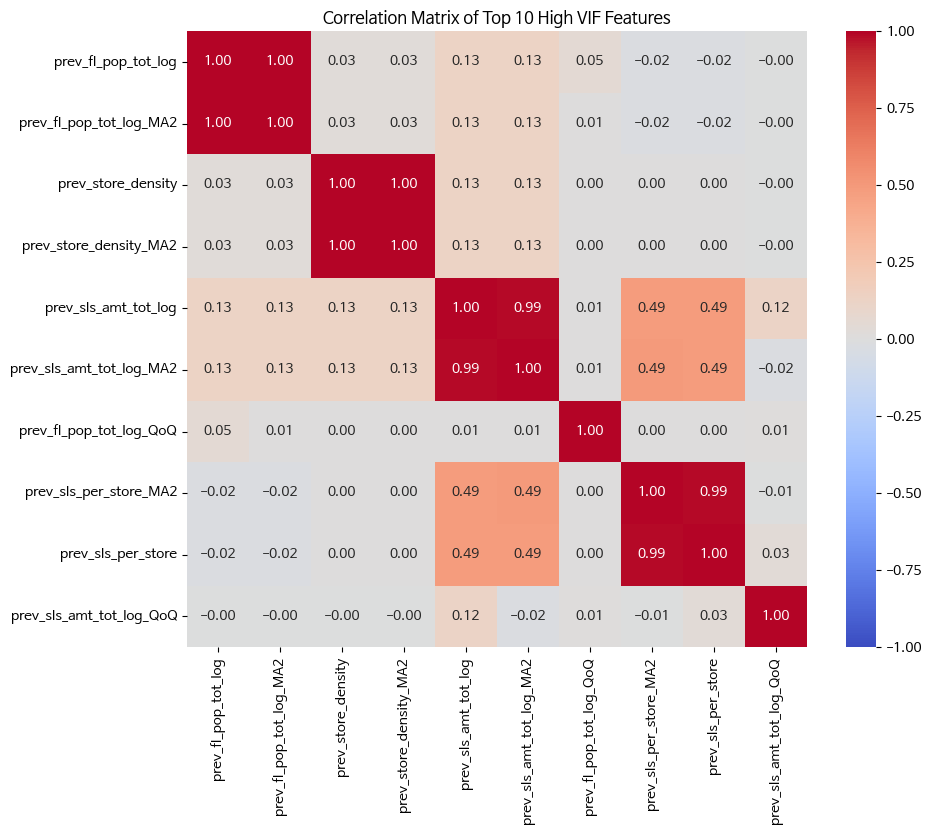

In [56]:
# 1. X_vif에서 VIF 지수 높은 일부 피처 제거
passed_features2 = [
  'prev_sls_amt_tot_log', 'prev_fl_pop_tot_log', 'prev_wk_pop_tot_log', 'prev_rs_pop_tot_log',
  'prev_apt_avg_price_log', 'prev_edu_cnt', 'prev_traffic_score',
  'prev_sls_per_store', 'prev_store_density',
  'prev_ATV', 'prev_conversion_rate', 'prev_franchise_ratio',
  'prev_rs_pop_ratio',
  'prev_wk_pop_ratio',
  'prev_exp_food_ratio', 'prev_sls_wkdy_ratio',
  'prev_sls_lunch_ratio', 'prev_sls_afternoon_ratio', 'prev_sls_evening_ratio', 'prev_sls_night_ratio',
  'prev_sls_2030s_ratio', 'prev_sls_3050s_ratio', 'prev_sls_60s_ratio',
  'prev_cluster_id',

  # 시계열 파생 변수
  'prev_sls_amt_tot_log_MA2', 'prev_sls_amt_tot_log_STD2','prev_sls_amt_tot_log_QoQ',
  'prev_sls_per_store_MA2', 'prev_sls_per_store_STD2',
  'prev_ATV_MA2', 'prev_ATV_STD2', 'prev_ATV_QoQ',
  'prev_fl_pop_tot_log_MA2', 'prev_fl_pop_tot_log_STD2', 'prev_fl_pop_tot_log_QoQ',
  'prev_store_density_MA2', 'prev_store_density_STD2', 'prev_store_density_QoQ',
]
X_vif2 = X_vif[passed_features2].copy()

# 2. VIF 계산을 위한 전처리
# statsmodels VIF 계산을 위해 상수항(Intercept) 추가 필수
X_vif2.insert(0, 'const', 1.0)

# 3. VIF 계산
vif2_data = pd.DataFrame()
vif2_data["Feature"] = X_vif2.columns
vif2_data["VIF"] = [variance_inflation_factor(X_vif2.values, i) for i in range(X_vif2.shape[1])]

# 4. 결과 출력 (상수항 제외, VIF 높은 순 정렬)
vif2_data = vif2_data[vif2_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False).reset_index(drop=True)

print("=== VIF(분산팽창지수) 계산 결과 ===")
display(vif2_data.head(20))

# 5. 상관행렬 시각화 (VIF가 높은 상위 10개 변수 간의 관계 파악)
top_10_vif_features = vif2_data['Feature'].head(10).tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(X_vif2[top_10_vif_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Top 10 High VIF Features")
plt.show()

=== VIF(분산팽창지수) 계산 결과 ===


,Feature,VIF
0,prev_cluster_id,2.914162
1,prev_sls_night_ratio,2.910262
2,prev_sls_evening_ratio,2.607648
3,prev_sls_afternoon_ratio,2.601128
4,prev_sls_lunch_ratio,2.542787
5,prev_ATV_STD2,2.462746
6,prev_sls_60s_ratio,2.329188
7,prev_ATV,2.177111
8,prev_fl_pop_tot_log,2.173381
9,prev_rs_pop_ratio,2.169430


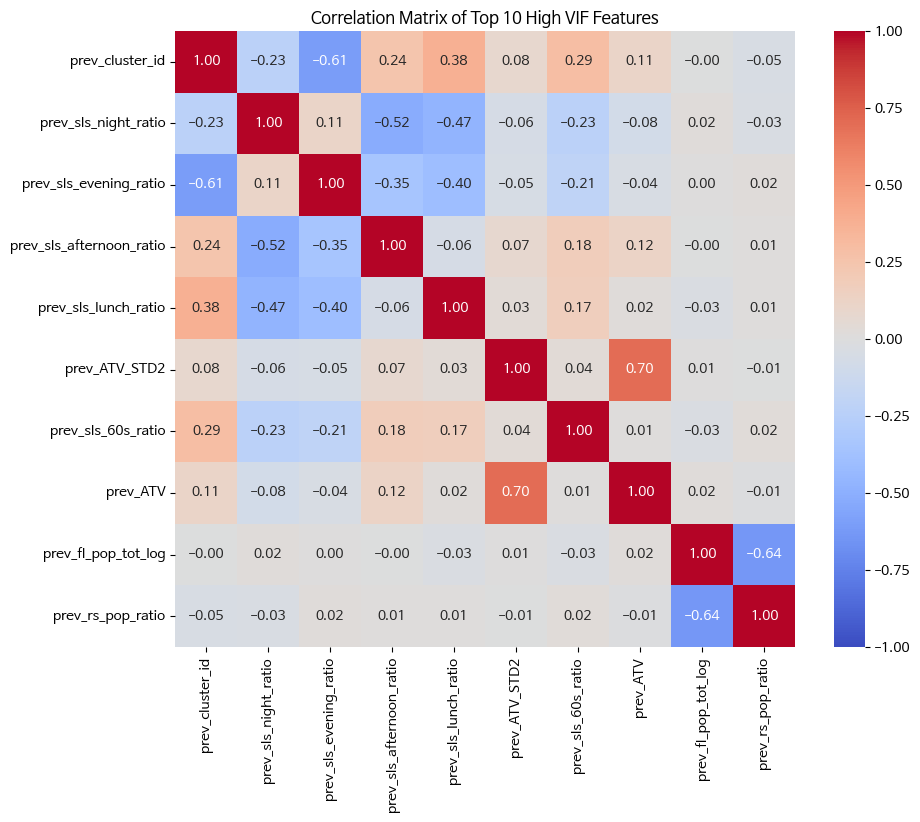

In [57]:
# 1. X_vif2에서 VIF 지수 높은 일부 피처 제거
passed_features3 = [
  'prev_sls_amt_tot_log', 'prev_fl_pop_tot_log',
  'prev_apt_avg_price_log', 'prev_edu_cnt', 'prev_traffic_score',
  'prev_sls_per_store', 'prev_store_density',
  'prev_ATV', 'prev_conversion_rate', 'prev_franchise_ratio',
  'prev_rs_pop_ratio',
  'prev_wk_pop_ratio',
  'prev_exp_food_ratio', 'prev_sls_wkdy_ratio',
  'prev_sls_lunch_ratio', 'prev_sls_afternoon_ratio', 'prev_sls_evening_ratio', 'prev_sls_night_ratio',
  'prev_sls_2030s_ratio', 'prev_sls_3050s_ratio', 'prev_sls_60s_ratio',
  'prev_cluster_id',

  # 시계열 파생 변수
  'prev_sls_amt_tot_log_STD2', 'prev_sls_amt_tot_log_QoQ',
  'prev_sls_per_store_STD2',
  'prev_ATV_STD2', 'prev_ATV_QoQ',
  'prev_fl_pop_tot_log_STD2', 'prev_fl_pop_tot_log_QoQ',
  'prev_store_density_STD2', 'prev_store_density_QoQ',
]
X_vif3 = X_vif2[passed_features3].copy()

# 2. VIF 계산을 위한 전처리
# statsmodels VIF 계산을 위해 상수항(Intercept) 추가 필수
X_vif3.insert(0, 'const', 1.0)

# 3. VIF 계산
vif3_data = pd.DataFrame()
vif3_data["Feature"] = X_vif3.columns
vif3_data["VIF"] = [variance_inflation_factor(X_vif3.values, i) for i in range(X_vif3.shape[1])]

# 4. 결과 출력 (상수항 제외, VIF 높은 순 정렬)
vif3_data = vif3_data[vif3_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False).reset_index(drop=True)

print("=== VIF(분산팽창지수) 계산 결과 ===")
display(vif3_data)

# 5. 상관행렬 시각화 (VIF가 높은 상위 10개 변수 간의 관계 파악)
top_10_vif_features = vif3_data['Feature'].head(10).tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(X_vif3[top_10_vif_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Top 10 High VIF Features")
plt.show()

In [59]:
print("=== 가설 검정 & VIF 검사 완료 ===")
print("학습에 사용될 피처 개수:", len(passed_features3))
print("\n")

final_features = id_features + passed_features3 + ['target_class']
df_model = df_temp[final_features].sort_values([ 'yq_cd', 'dong_cd', 'biz_cd']).reset_index(drop=True)
df_model

=== 가설 검정 & VIF 검사 완료 ===
학습에 사용될 피처 개수: 31




,yq_cd,dong_cd,biz_cd,prev_sls_amt_tot_log,prev_fl_pop_tot_log,prev_apt_avg_price_log,prev_edu_cnt,prev_traffic_score,prev_sls_per_store,prev_store_density,...,prev_sls_amt_tot_log_STD2,prev_sls_amt_tot_log_QoQ,prev_sls_per_store_STD2,prev_ATV_STD2,prev_ATV_QoQ,prev_fl_pop_tot_log_STD2,prev_fl_pop_tot_log_QoQ,prev_store_density_STD2,prev_store_density_QoQ,target_class
0,20192,11110515,CS100001,21.386510,15.115219,19.310098,6.0,3.295837,2.426349e+07,0.000031,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
1,20192,11110515,CS100002,17.419450,15.115219,19.310098,6.0,3.295837,7.348538e+06,0.000002,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
2,20192,11110515,CS100003,18.726846,15.115219,19.310098,6.0,3.295837,1.234734e+07,0.000004,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
3,20192,11110515,CS100004,20.719550,15.115219,19.310098,6.0,3.295837,3.213841e+07,0.000012,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
4,20192,11110515,CS100005,20.369441,15.115219,19.310098,6.0,3.295837,3.342846e+07,0.000008,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391345,20244,11740700,CS300031,17.366676,15.713550,19.383703,6.0,5.575949,3.872658e+06,0.000006,...,0.508136,0.043165,1.403618e+06,59667.773639,-0.183778,0.005232,-0.000471,0.000000,0.000000,2
391346,20244,11740700,CS300033,18.995045,15.713550,19.383703,6.0,5.575949,2.960002e+07,0.000004,...,0.331008,0.025267,7.824179e+06,27774.593952,0.685560,0.005232,-0.000471,0.000000,0.000000,2
391347,20244,11740700,CS300035,19.843512,15.713550,19.383703,6.0,5.575949,2.440499e+07,0.000011,...,0.116170,-0.008211,3.081302e+06,3865.813819,-0.094837,0.005232,-0.000471,0.000000,0.000000,2
391348,20244,11740700,CS300036,15.308850,15.713550,19.383703,6.0,5.575949,4.451937e+05,0.000006,...,0.085532,-0.007839,4.047727e+04,64.205976,-0.008132,0.005232,-0.000471,0.000000,0.000000,2


In [60]:
from google.colab import drive
import os

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 저장할 경로와 파일명 설정
save_path = '/content/drive/MyDrive/df_model.csv'

# 3. CSV 파일로 내보내기
df_model.to_csv(save_path, index=False, encoding='utf-8-sig')

print(f"✅ 드라이브에 파일 저장이 완료되었습니다!\n경로: {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 드라이브에 파일 저장이 완료되었습니다!
경로: /content/drive/MyDrive/df_model.csv
